In [1]:
from setup import * 

# 1D Fickian diffusion 
henry_constant = 9.3e-4 * 1000 # mol/m^3/atm for CO in water at 293.15K 
diffusion_coefficient = 1.91e-9 # m2/s for CO in water at 293.15K 
A_site = F * 1e-4 / (210e-6 * N_A) # Surface area of a single Pt site: 1cm2 = 210uC (HUPD)
delta_BL_micron = 1e-6 # Setting the denominator to 1 micron to allow for delta_BL to be in microns
k1_fick = diffusion_coefficient * henry_constant * N_A * A_site / delta_BL_micron
log_k1_fick = np.log(k1_fick)

# ER 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.57,15
,3000,0,0.50,3
,3000,0,0.51,7
,3000,0,0.58,15


Computed from 4000 posterior samples and 581 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  1072.82    33.45
p_loo       10.89        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      581  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



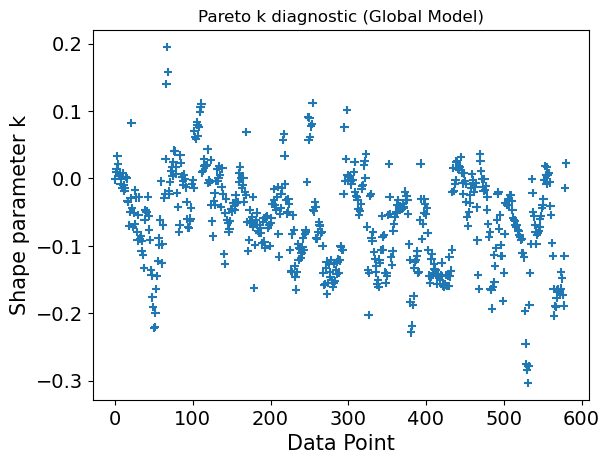

In [2]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_model = log_k2 + log_theta_CO + np.log(C_KOH_in)
    log_rate = observables(log_rate_model) 

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.135  0.002  -0.139   -0.131        0.0      0.0    2281.0    2813.0    1.0
deltaG4_0 -0.001  0.007  -0.014    0.013        0.0      0.0    1554.0    2167.0    1.0
Gact2_0    0.751  0.001   0.749    0.752        0.0      0.0    1670.0    2147.0    1.0
beta_2     0.258  0.007   0.245    0.272        0.0      0.0    1580.0    2106.0    1.0
sigma      0.473  0.021   0.434    0.511        0.0      0.0    3524.0    2661.0    1.0


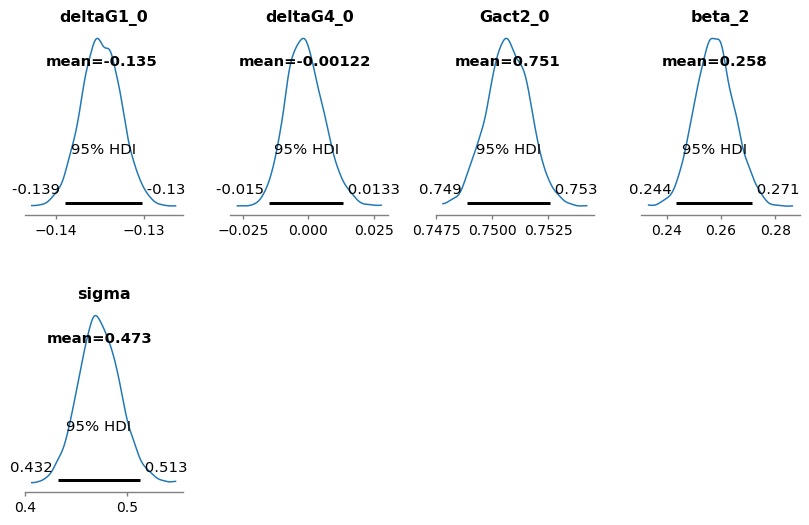

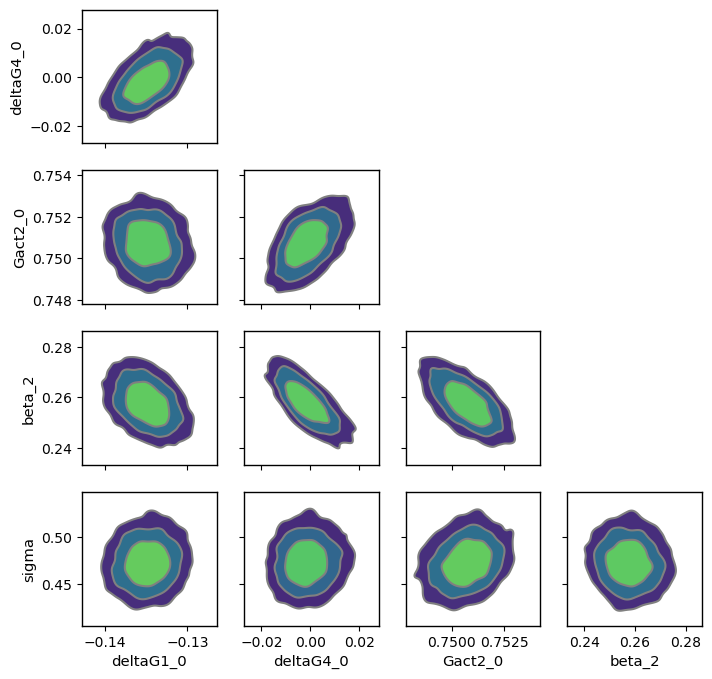

Sampling: [rate]


rate: 0.696


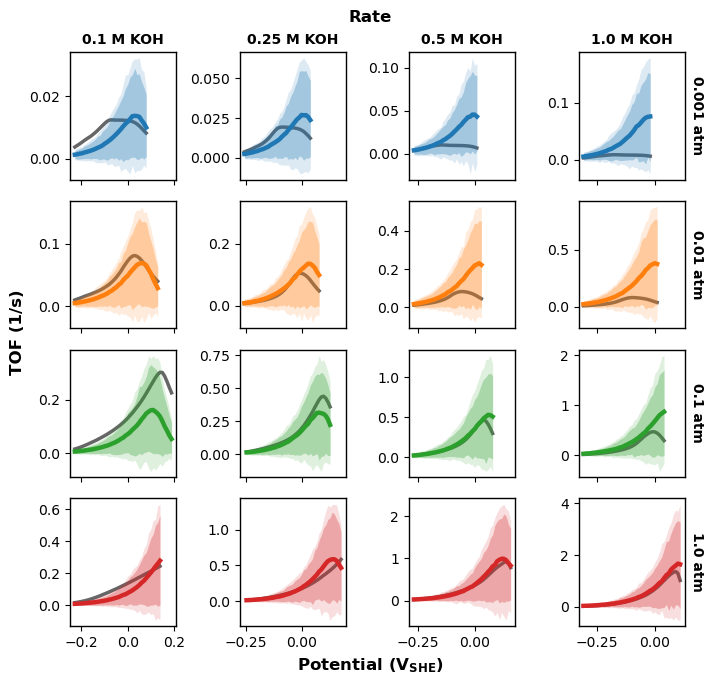

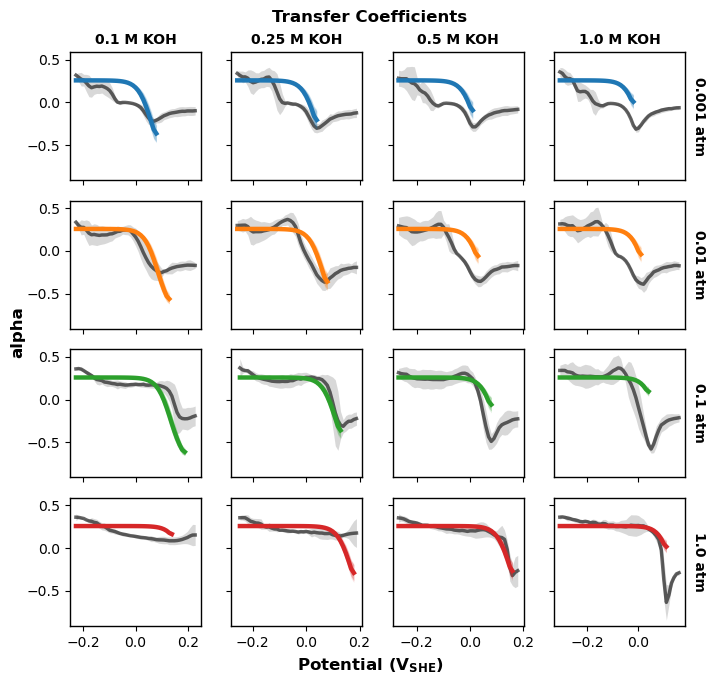

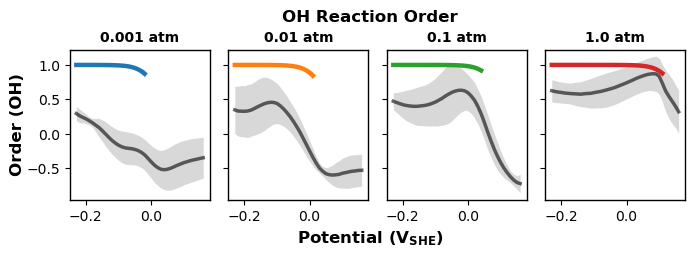

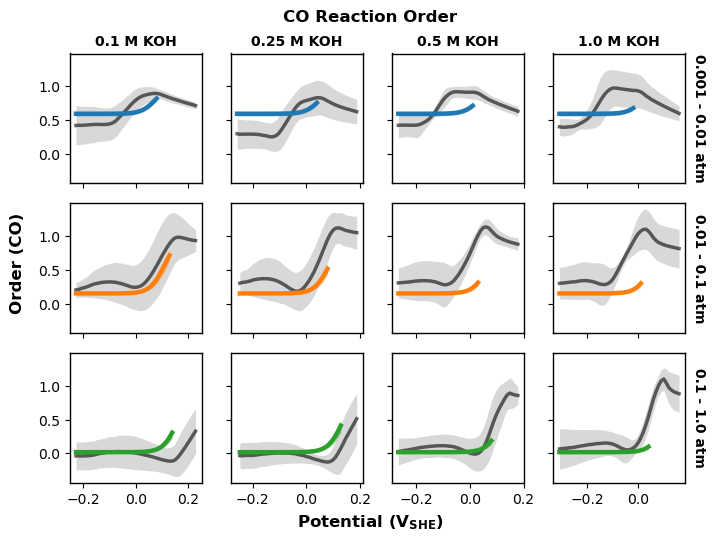

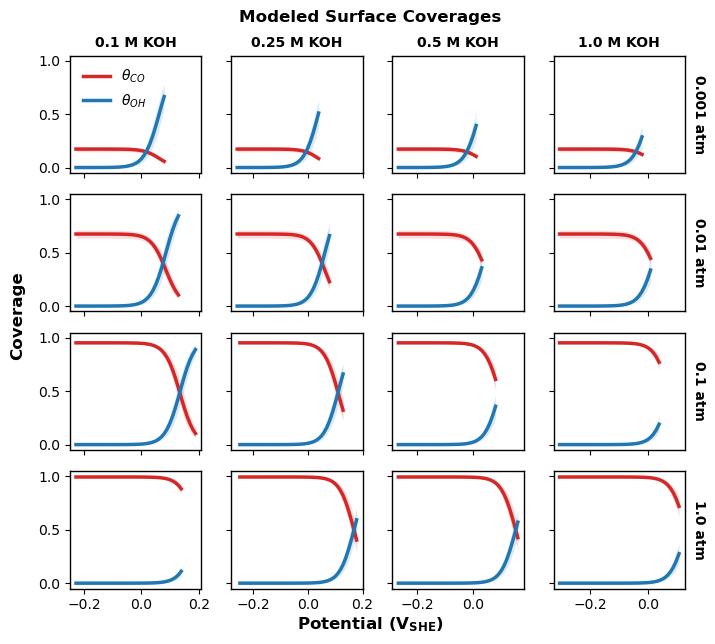

In [3]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2, plot_target)
plot_model_fits(trace_ER_2, ppc_ER_2); plot_coverages(trace_ER_2)

# LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.57,15
,3000,0,0.52,7
,3000,0,0.61,7
,3000,0,0.54,11


Computed from 4000 posterior samples and 581 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -118.19    60.95
p_loo       17.18        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      581  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



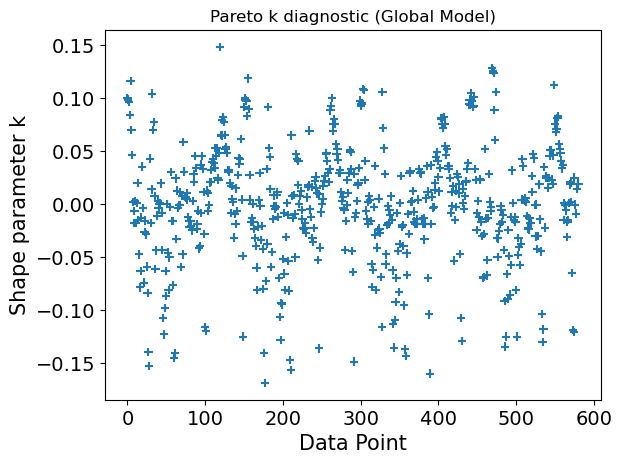

In [4]:
with pm.Model() as LH_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in) 
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_model = log_k2 + log_theta_CO + log_theta_OH 
    log_rate = observables(log_rate_model) 

trace_LH_2, loo_LH_2 = fit_and_evaluate(LH_2)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.068  0.002  -0.072   -0.063      0.000    0.000    2125.0    2474.0    1.0
deltaG4_0 -0.108  0.002  -0.111   -0.105      0.000    0.000    2640.0    2635.0    1.0
Gact2_0    0.663  0.002   0.659    0.667      0.000    0.000    1873.0    2087.0    1.0
sigma      1.476  0.093   1.309    1.652      0.002    0.002    2534.0    2272.0    1.0


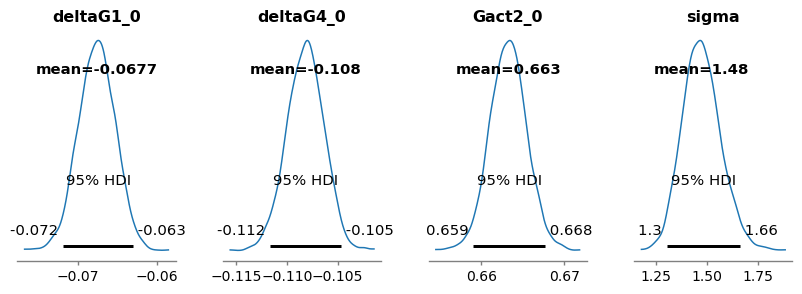

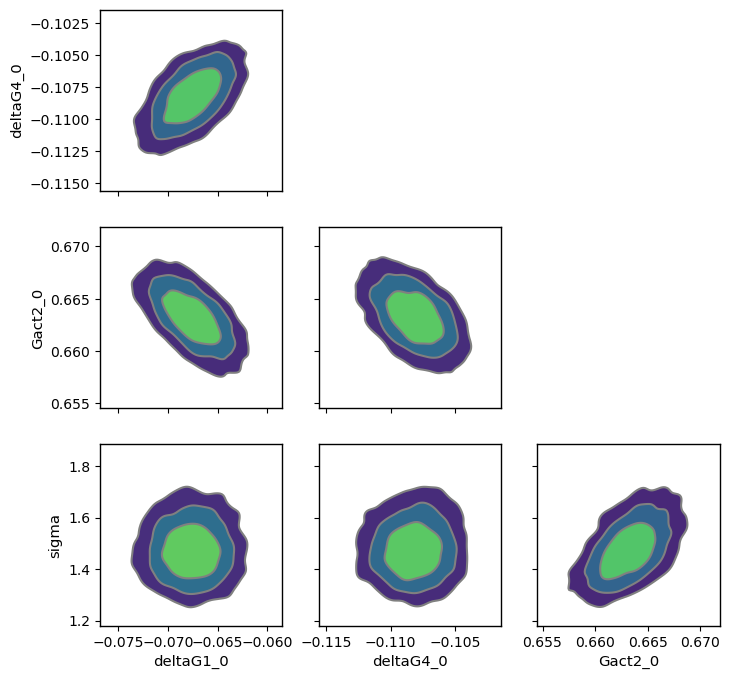

Sampling: [rate]


rate: 0.502


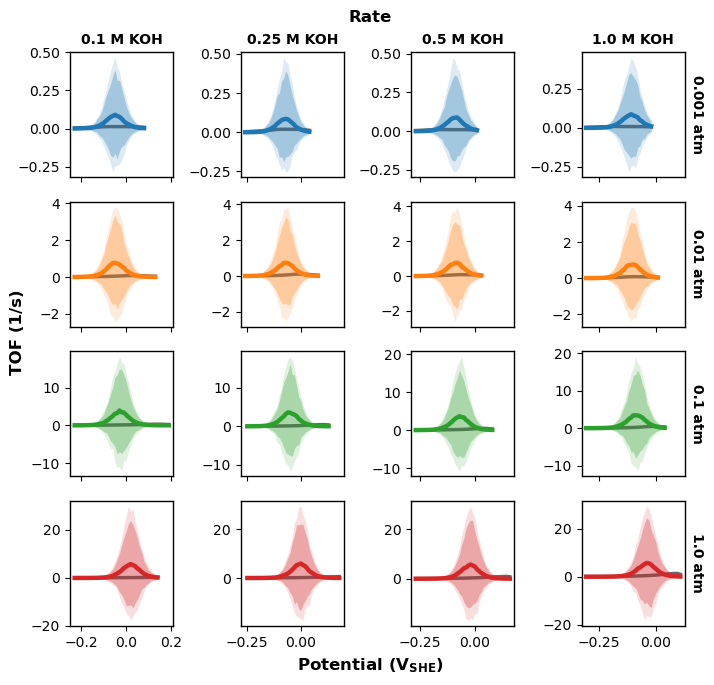

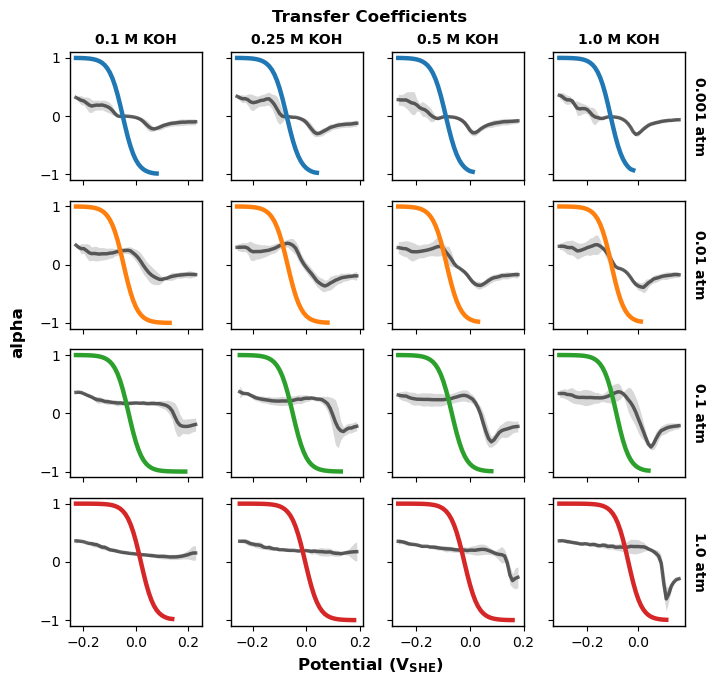

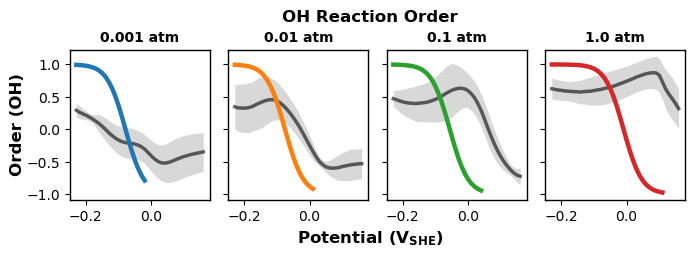

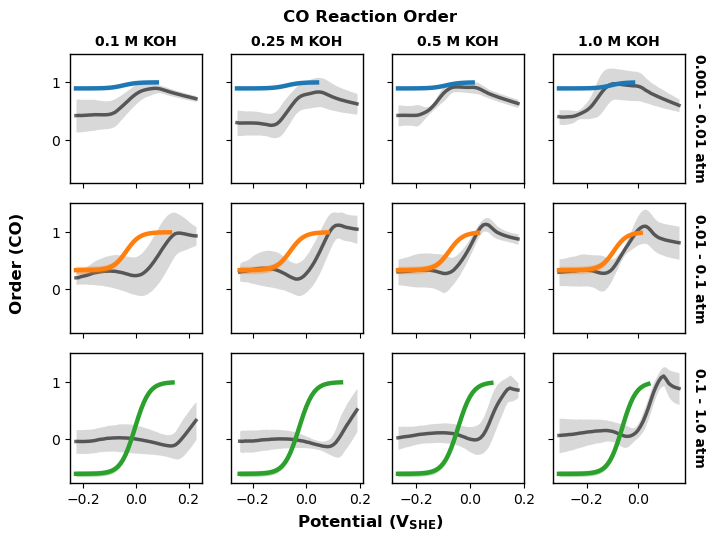

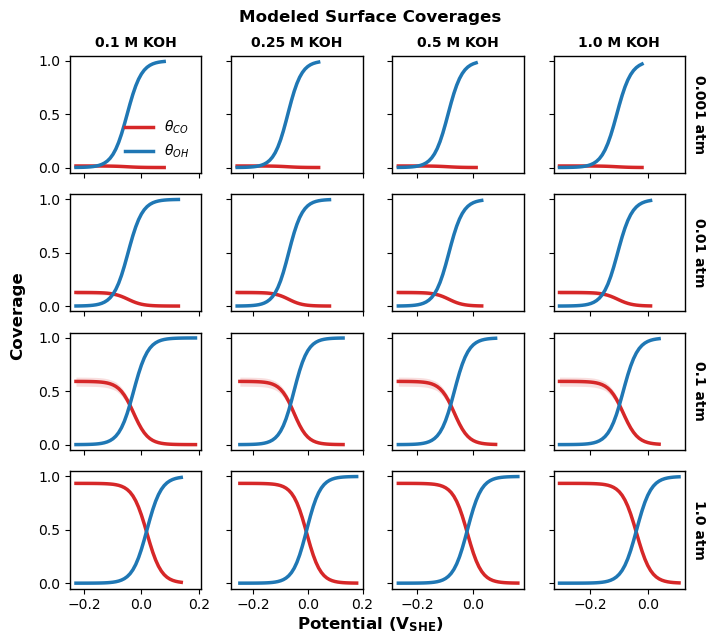

In [5]:
ppc_LH_2 = plot_posteriors(trace_LH_2, LH_2, plot_target)
plot_model_fits(trace_LH_2, ppc_LH_2); plot_coverages(trace_LH_2)

# Comparison
ELPD and sigma shows that ER_2 is the clear winner - we should work on creating complex models with ER_2 as the base. 

      rank     elpd_loo      p_loo   elpd_diff  weight         se        dse  warning scale
ER_2     0  1072.823523  10.887434     0.00000     1.0  33.451948   0.000000    False   log
LH_2     1  -118.194297  17.180792  1191.01782     0.0  60.949366  49.899203    False   log


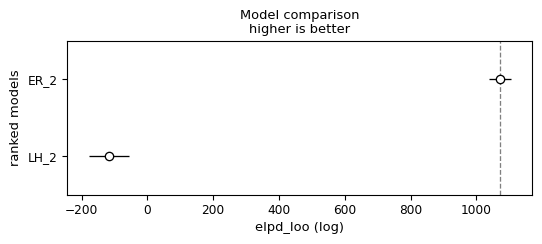

In [6]:
comparison_dict = {
    "LH_2": loo_LH_2,
    "ER_2": loo_ER_2,
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()

# ER LH 2
LH is dead, and the model collapses to ER_2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.44,15
,3000,0,0.39,7
,3000,0,0.37,7
,3000,0,0.40,7


Computed from 4000 posterior samples and 581 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  1072.50    33.41
p_loo       11.10        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      581  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



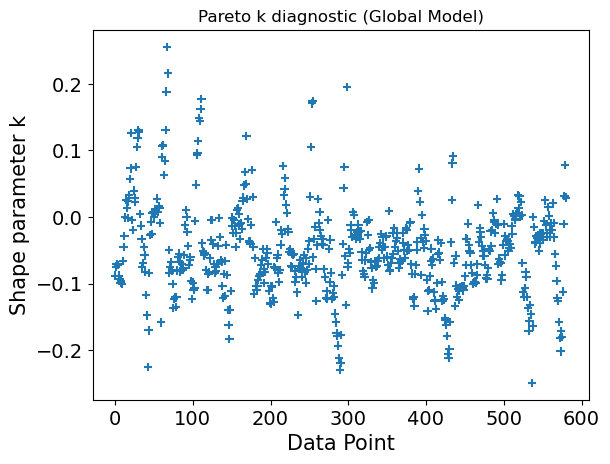

In [7]:
with pm.Model() as ER_LH_2:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH- -> COOH* + (e-) (RDS)
    2b. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.75, sigma=0.1) # at 0V_SHE
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.75, sigma=0.1) 

    # Thermodynamics
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0) 
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate_model = pt.logaddexp(log_rate_ER, log_rate_LH)
    log_rate = observables(log_rate_model)

    phi_LH = pm.Deterministic('phi_LH', pt.exp(log_rate_LH - log_rate_model))

trace_ER_LH_2, loo_ER_LH_2 = fit_and_evaluate(ER_LH_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.135  0.002  -0.139   -0.131      0.000    0.000    2660.0    2096.0    1.0
deltaG4_0  -0.002  0.008  -0.016    0.012      0.000    0.000    1875.0    2033.0    1.0
Gact2_ER_0  0.751  0.001   0.749    0.753      0.000    0.000    1754.0    2033.0    1.0
Gact2_LH_0  0.879  0.053   0.800    0.982      0.001    0.001    1814.0    1475.0    1.0
beta_2      0.257  0.007   0.243    0.271      0.000    0.000    1856.0    2039.0    1.0
sigma       0.474  0.021   0.436    0.512      0.000    0.000    3117.0    2761.0    1.0


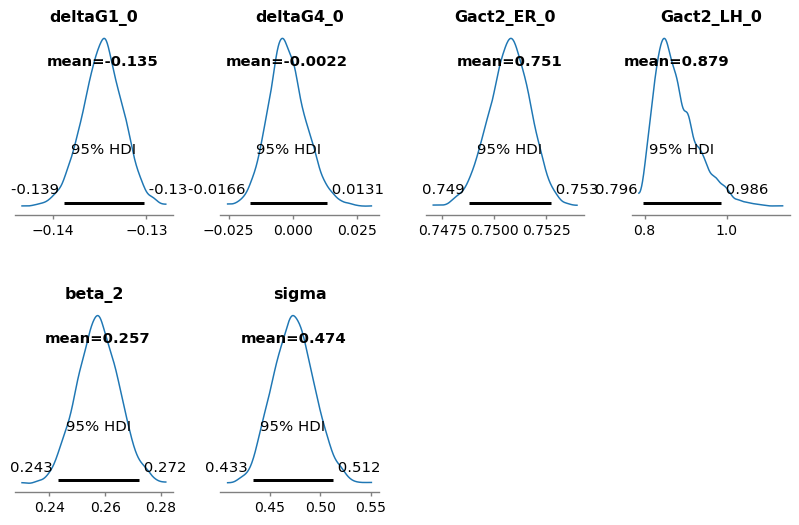

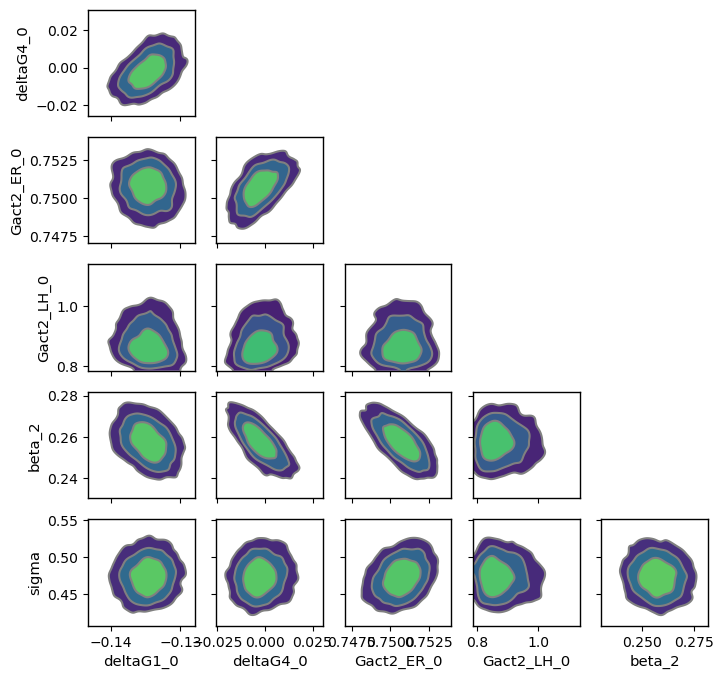

Sampling: [rate]


rate: 0.698


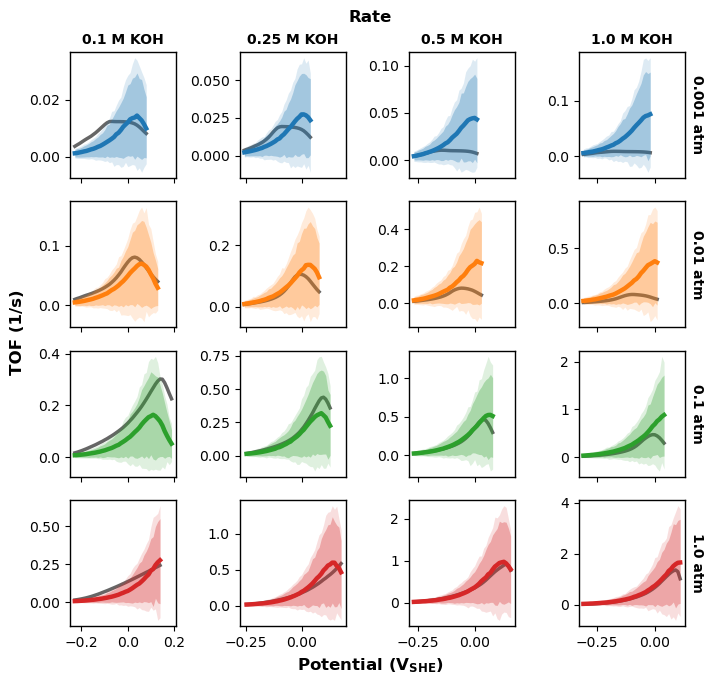

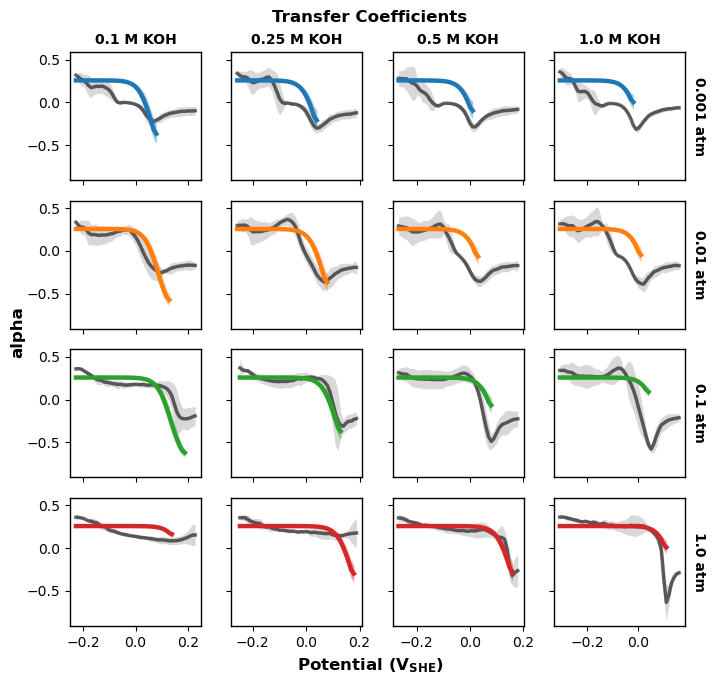

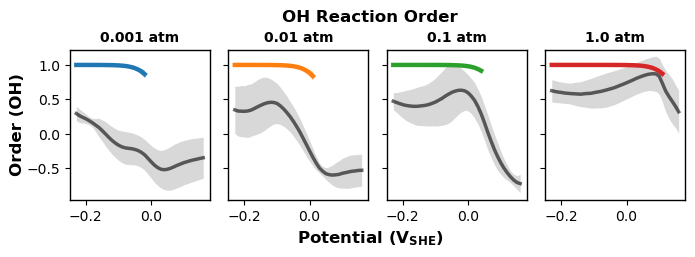

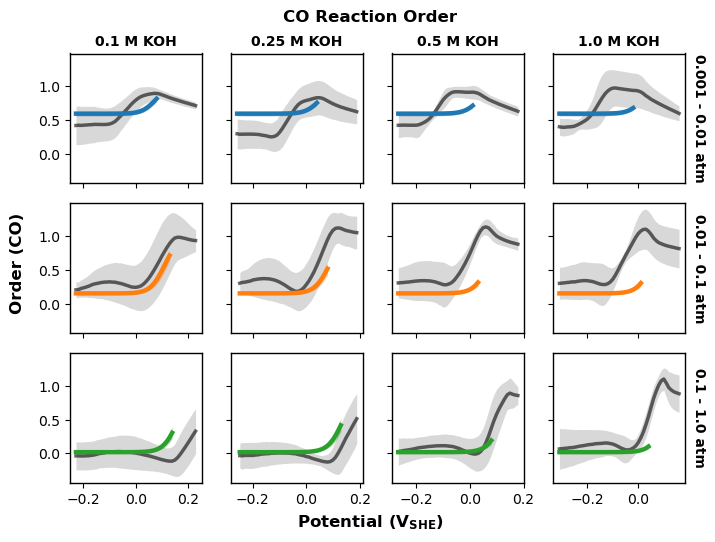

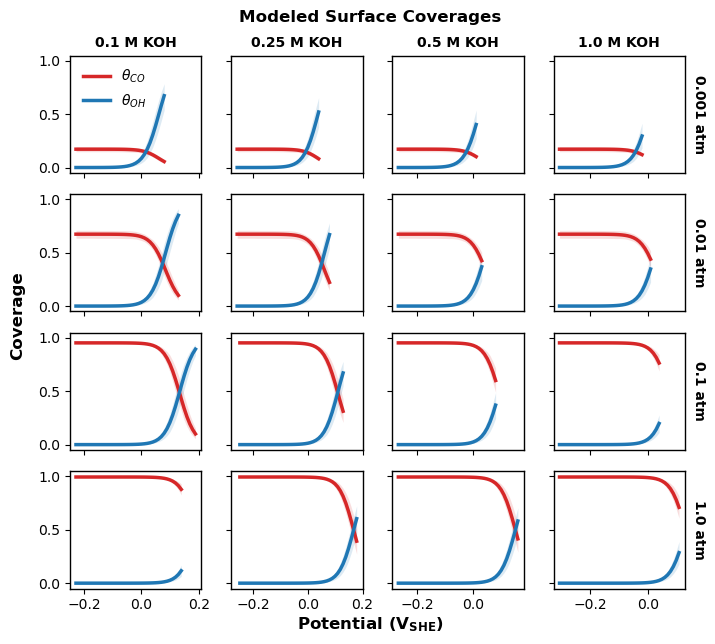

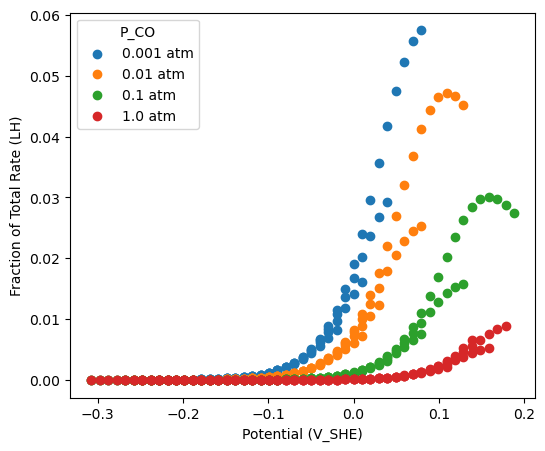

In [8]:
ppc_ER_LH_2 = plot_posteriors(trace_ER_LH_2, ER_LH_2, plot_target)
plot_model_fits(trace_ER_LH_2, ppc_ER_LH_2); plot_coverages(trace_ER_LH_2)

phi_LH_mean = trace_ER_LH_2.posterior['phi_LH'].mean(dim=['chain', 'draw'])
plt.figure(figsize=(6, 5))
for p in np.unique(P_CO_in):
    mask = (P_CO_in == p)
    plt.scatter(E_in[mask], phi_LH_mean[mask], label=f'{p} atm')
plt.xlabel('Potential (V_SHE)')
plt.ylabel('Fraction of Total Rate (LH)')
plt.legend(title='P_CO')
plt.show()

# ER 2 3
Bimodal distribution - one with 3 more limited, other with 2 more limited 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.16,47
,3000,0,0.15,87
,3000,0,0.15,31
,3000,0,0.19,31


Computed from 4000 posterior samples and 581 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  1129.50    31.76
p_loo      133.35        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      581  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



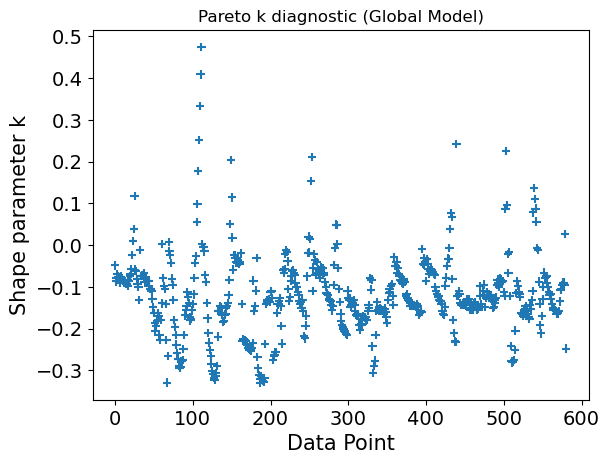

In [9]:
with pm.Model() as ER_2_3:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- <-> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (SSA)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG2_0 = pm.Normal('deltaG2_0', mu=0.0, sigma=0.2) 
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    beta_3 = pm.Beta('beta_3', alpha=5, beta=5)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.75, sigma=0.1)
    Gact3_0 = pm.Normal('Gact3_0', mu=0.75, sigma=0.1)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG2_ER = deltaG2_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in

    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K2_ER = -deltaG2_ER/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    term_COOH = log_k2_ER + term_CO + np.log(C_KOH_in) - pt.logaddexp(log_k2_ER - log_K2_ER, log_k3 + np.log(C_KOH_in))
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH, term_COOH]), axis=0) 

    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression
    log_rate_model = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    log_rate = observables(log_rate_model)

trace_ER_2_3, loo_ER_2_3 = fit_and_evaluate(ER_2_3, target_accept=0.95)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.127  0.007  -0.142   -0.117      0.003    0.002       8.0      42.0   1.47
deltaG4_0 -0.015  0.158  -0.288    0.130      0.075    0.040       7.0      33.0   1.54
deltaG2_0 -0.424  0.079  -0.569   -0.321      0.018    0.003      19.0     854.0   1.14
Gact2_0    0.699  0.088   0.545    0.753      0.044    0.025       7.0      37.0   1.53
Gact3_0    0.669  0.049   0.612    0.749      0.023    0.011       7.0      33.0   1.54
beta_2     0.385  0.348   0.161    0.995      0.173    0.100       7.0      30.0   1.54
beta_3     0.558  0.200   0.215    0.774      0.095    0.050       7.0      32.0   1.54
sigma      0.421  0.072   0.283    0.493      0.035    0.019       7.0      29.0   1.53


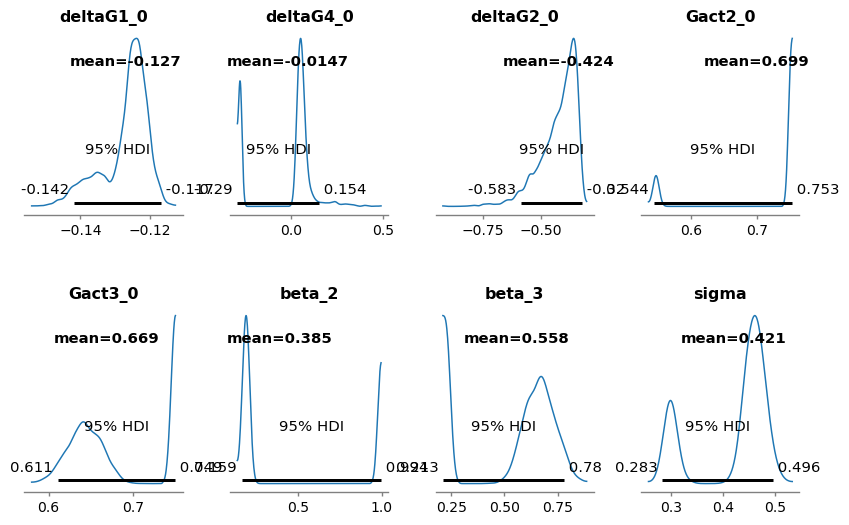

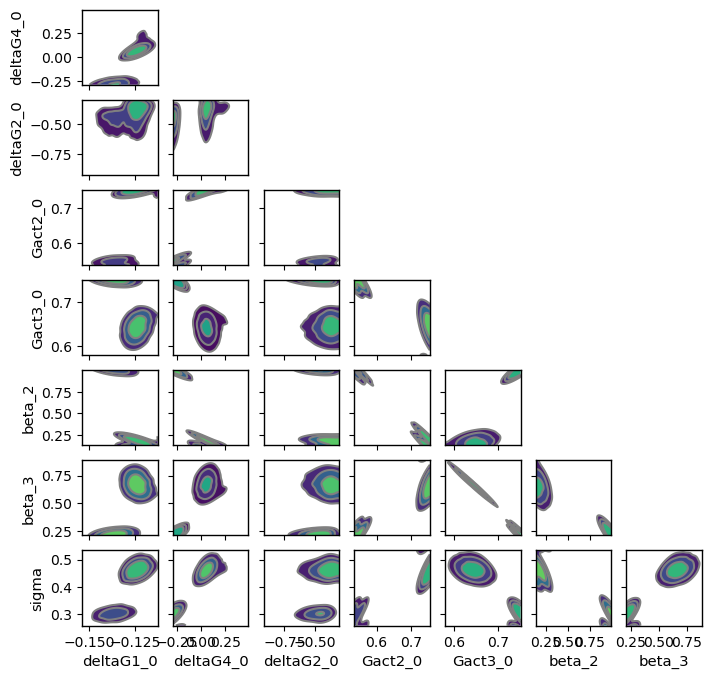

Sampling: [rate]


rate: 0.720


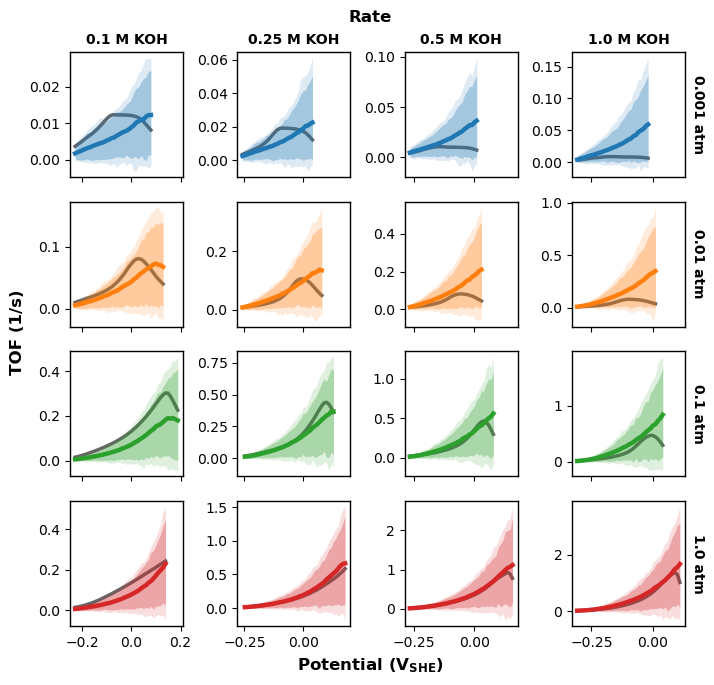

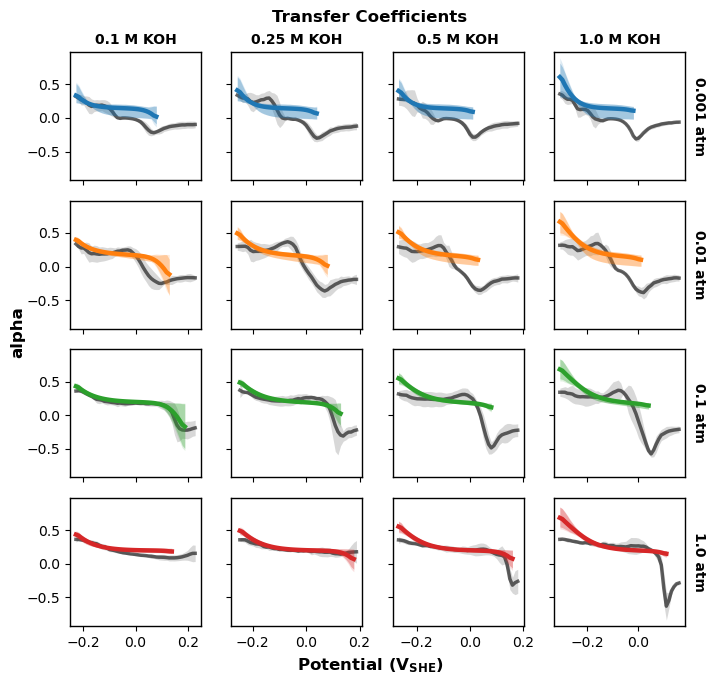

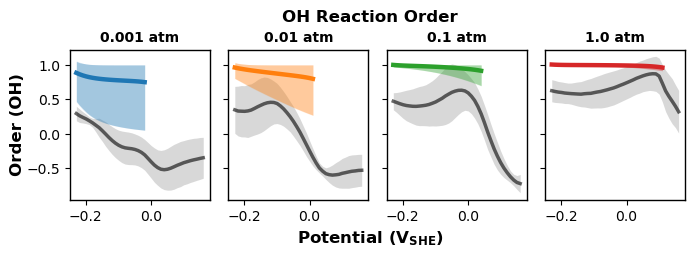

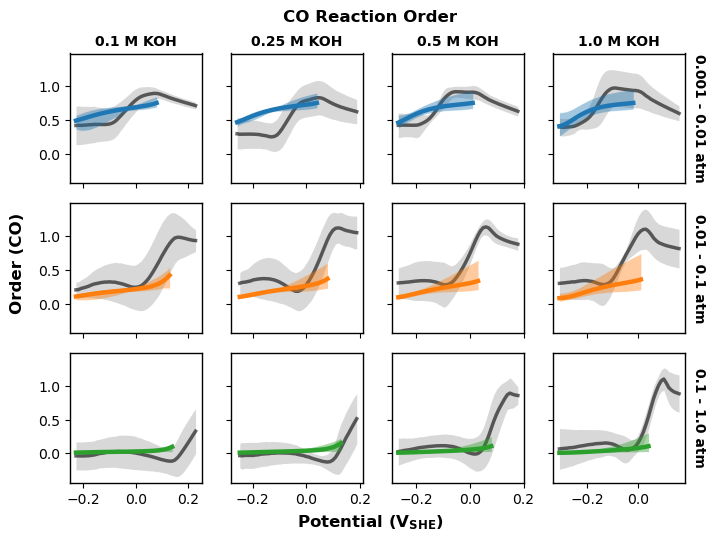

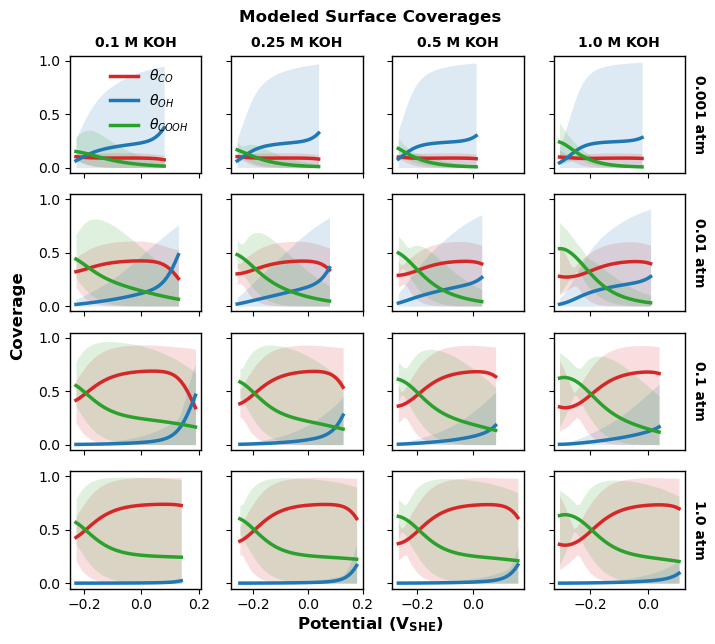

In [10]:
ppc_ER_2_3 = plot_posteriors(trace_ER_2_3, ER_2_3, plot_target)
plot_model_fits(trace_ER_2_3, ppc_ER_2_3); plot_coverages(trace_ER_2_3)

## Biased towards 2
2 should be more limited based on prior knowledge about CO OH combination being rate limited

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.13,31
,3000,0,0.14,63
,3000,0,0.17,15
,3000,0,0.13,111


Computed from 4000 posterior samples and 581 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  1101.19    31.86
p_loo       13.10        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      581  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



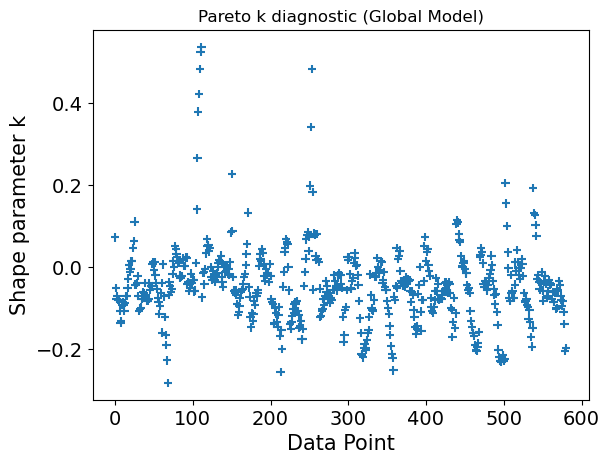

In [11]:
with pm.Model() as ER_2_3:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- <-> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (SSA)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG2_0 = pm.Normal('deltaG2_0', mu=-0.4, sigma=0.2) 
    beta_2 = pm.TruncatedNormal('beta_2', mu=0.25, sigma=0.1, upper=0.3)
    beta_3 = pm.Beta('beta_3', alpha=5, beta=5)
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.75, sigma=0.1, lower=0.72)
    Gact3_0 = pm.TruncatedNormal('Gact3_0', mu=0.65, sigma=0.1, upper=0.72)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG2_ER = deltaG2_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in

    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K2_ER = -deltaG2_ER/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    term_COOH = log_k2_ER + term_CO + np.log(C_KOH_in) - pt.logaddexp(log_k2_ER - log_K2_ER, log_k3 + np.log(C_KOH_in))
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH, term_COOH]), axis=0) 

    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression
    log_rate_model = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    log_rate = observables(log_rate_model)

trace_ER_2_3, loo_ER_2_3 = fit_and_evaluate(ER_2_3, target_accept=0.95)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.124  0.003  -0.130   -0.119      0.000    0.000     830.0    1577.0   1.00
deltaG4_0  0.072  0.063   0.008    0.151      0.003    0.008     687.0     464.0   1.00
deltaG2_0 -0.507  0.133  -0.749   -0.325      0.004    0.003    1021.0    1218.0   1.00
beta_2     0.185  0.015   0.157    0.212      0.001    0.000     705.0     947.0   1.00
beta_3     0.683  0.076   0.545    0.823      0.003    0.002     568.0     750.0   1.01
Gact2_0    0.750  0.001   0.748    0.752      0.000    0.000    1243.0    1202.0   1.00
Gact3_0    0.639  0.021   0.600    0.679      0.001    0.000     556.0     761.0   1.01
sigma      0.462  0.019   0.426    0.498      0.000    0.000    3934.0    2847.0   1.00


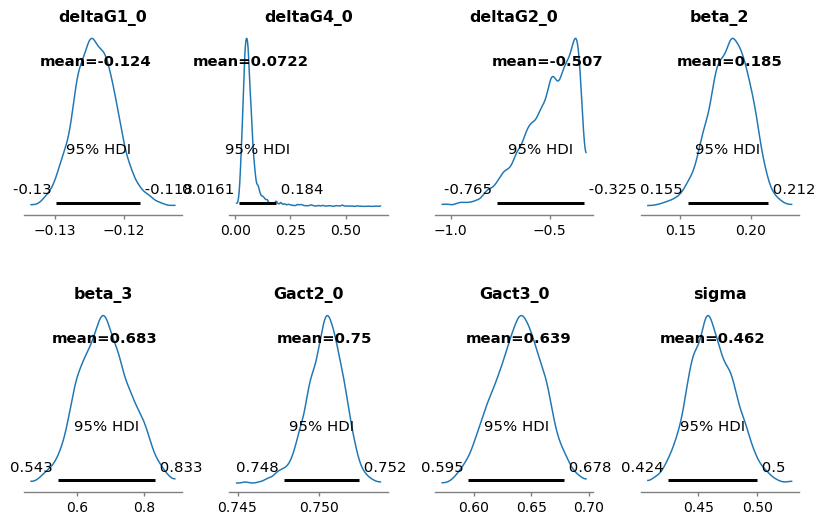

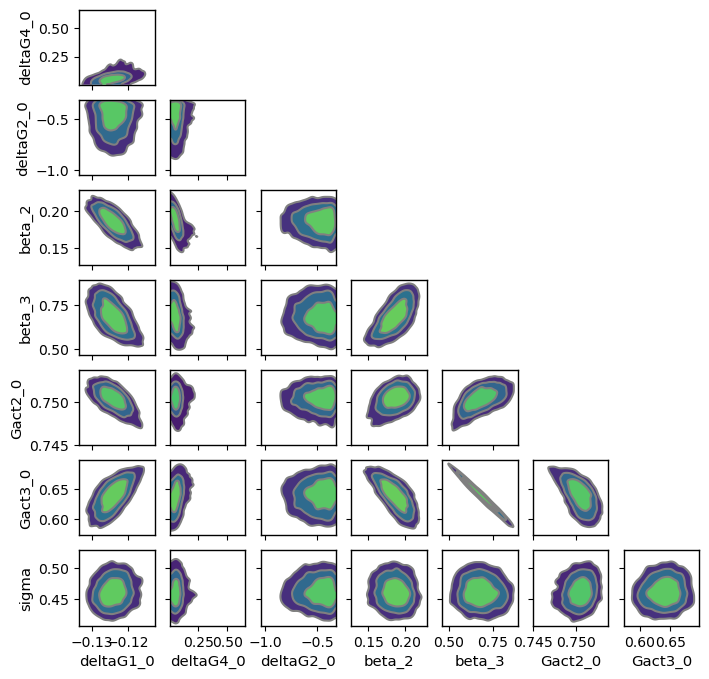

Sampling: [rate]


rate: 0.696


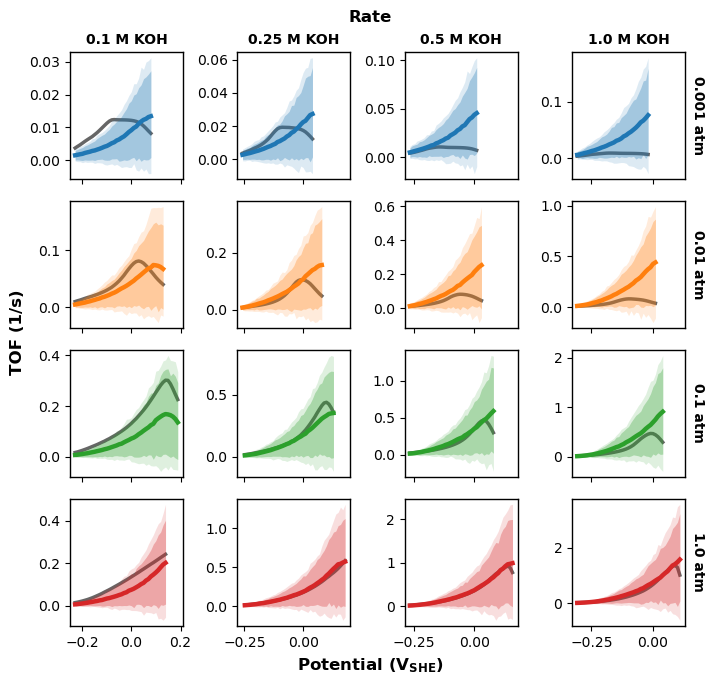

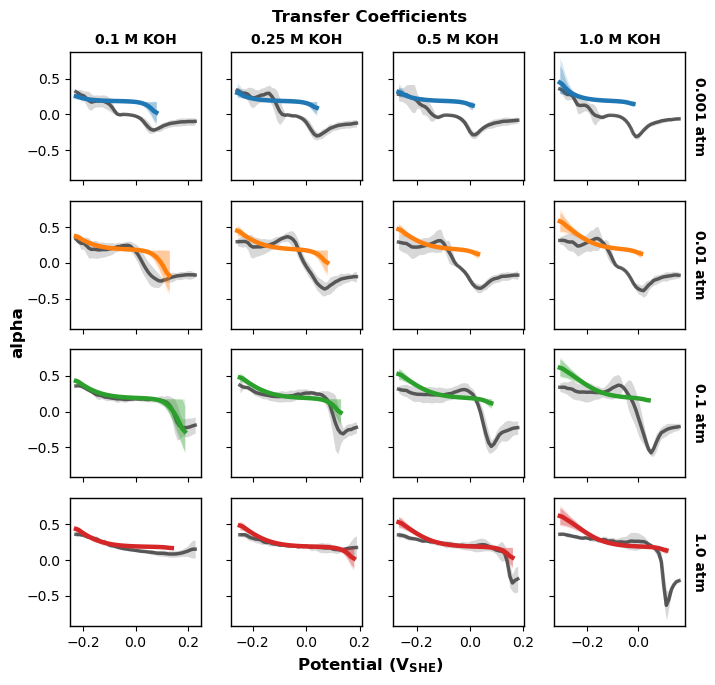

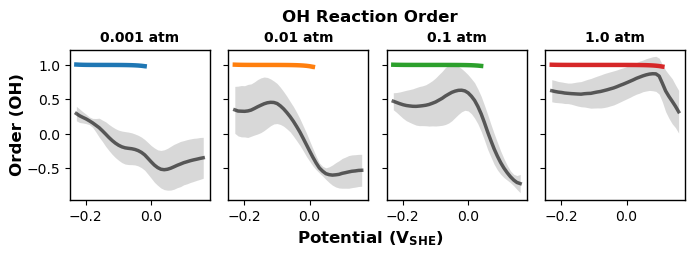

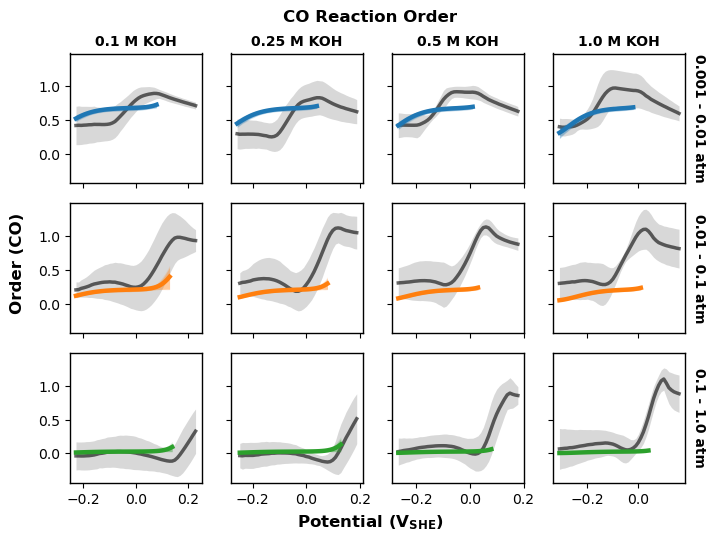

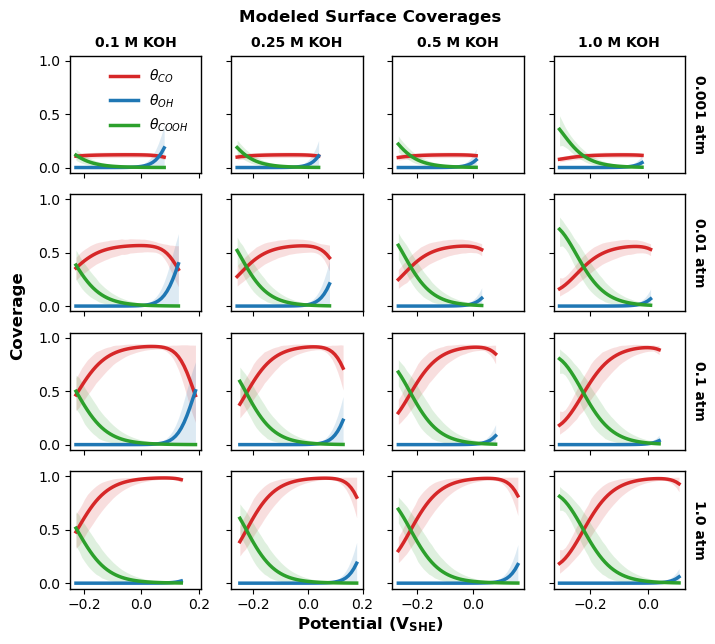

In [12]:
ppc_ER_2_3 = plot_posteriors(trace_ER_2_3, ER_2_3, plot_target)
plot_model_fits(trace_ER_2_3, ppc_ER_2_3); plot_coverages(trace_ER_2_3)

# ER 1 2
CO adsorption is limited!

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.48,15
,3000,0,0.50,15
,3000,0,0.36,7
,3000,0,0.52,7


Computed from 4000 posterior samples and 581 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -3586.85   108.32
p_loo     1315.40        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      581  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



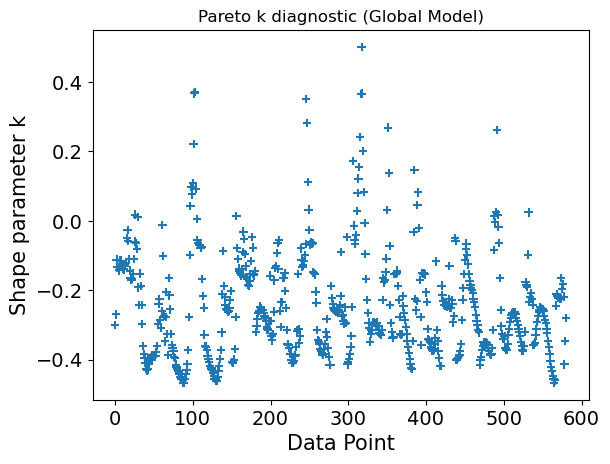

In [2]:
with pm.Model() as ER_1_2: 
    '''
    1. CO + * -> CO* (Fick) (Irr) (SSA)
    2. CO* + OH- -> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.75, sigma=0.1) # at 0V_SHE
    delta_BL = pm.TruncatedNormal('delta_BL', mu=10, sigma=5, lower=0) # in microns

    # Thermodynamics 
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1 = log_k1_fick - pt.log(delta_BL)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_k1 + np.log(P_CO_in) - (log_k2 + np.log(C_KOH_in))
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_model = log_k2 + np.log(C_KOH_in) + log_theta_CO 
    log_rate = observables(log_rate_model) 

    phi_fick = pm.Deterministic('phi_fick', pt.exp(log_k1 + np.log(P_CO_in) - log_rate_model))

trace_ER_1_2, loo_ER_1_2 = fit_and_evaluate(ER_1_2)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0  0.080  0.018   0.061    0.103      0.009    0.002       5.0      32.0   2.10
Gact2_0    0.742  0.001   0.742    0.744      0.000    0.000       5.0      33.0   1.98
beta_2     0.314  0.015   0.288    0.327      0.007    0.004       5.0      33.0   2.10
delta_BL   7.794  0.127   7.577    8.047      0.055    0.026       5.0      30.0   1.97


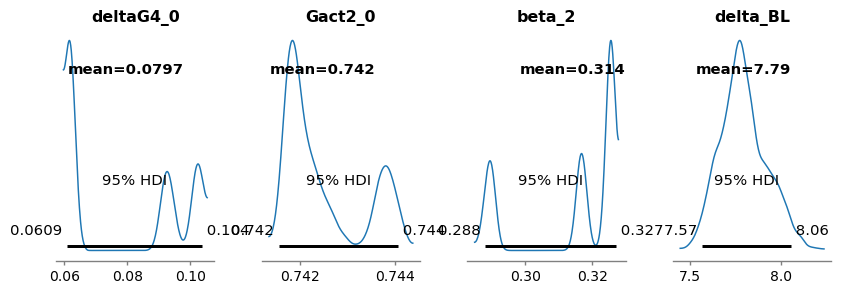

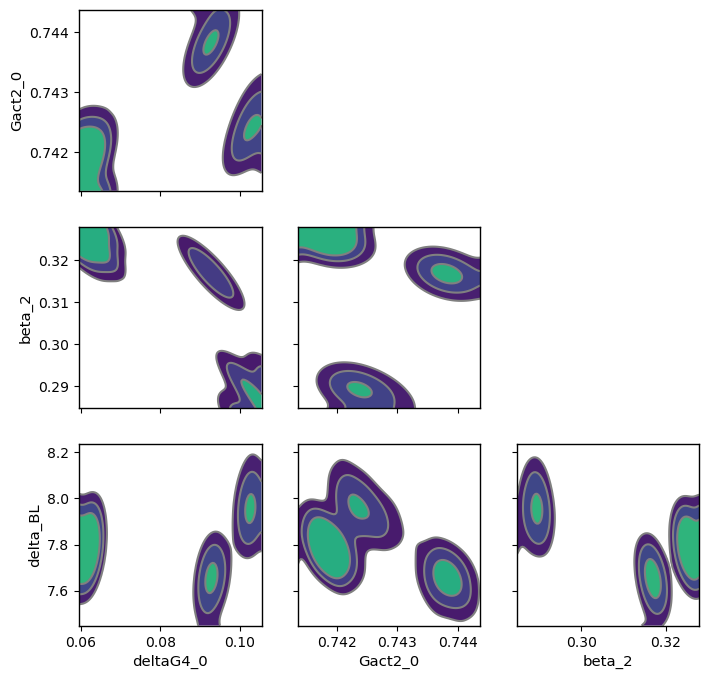

Sampling: [rate]


rate: 0.875


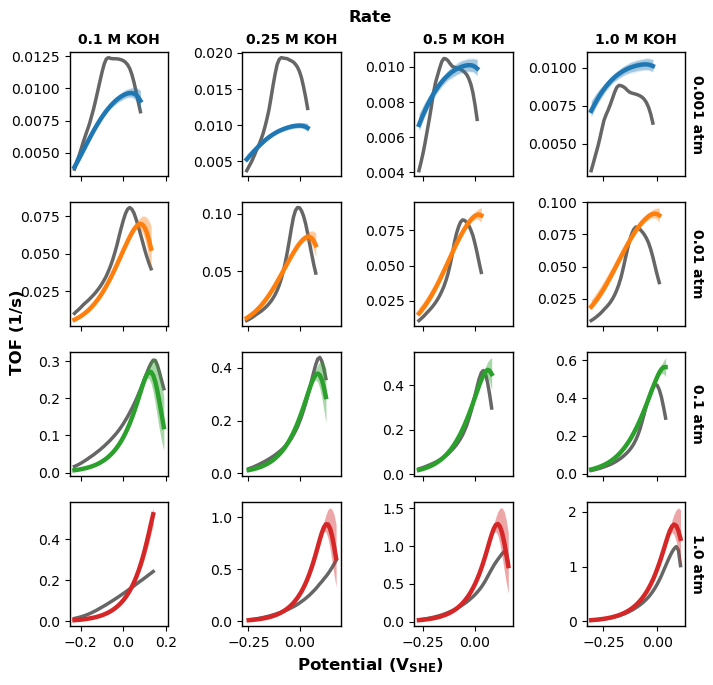

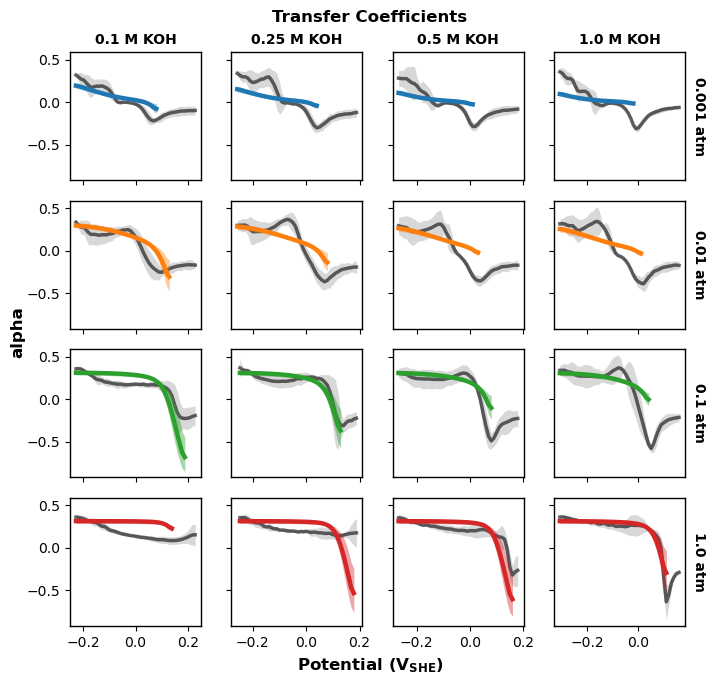

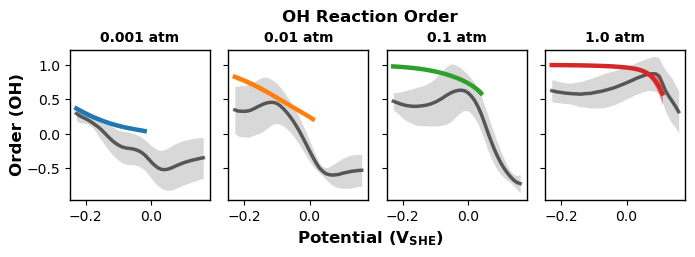

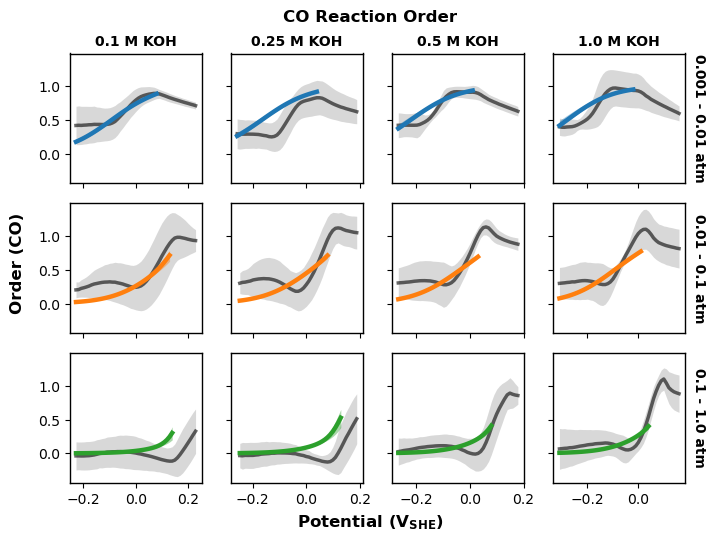

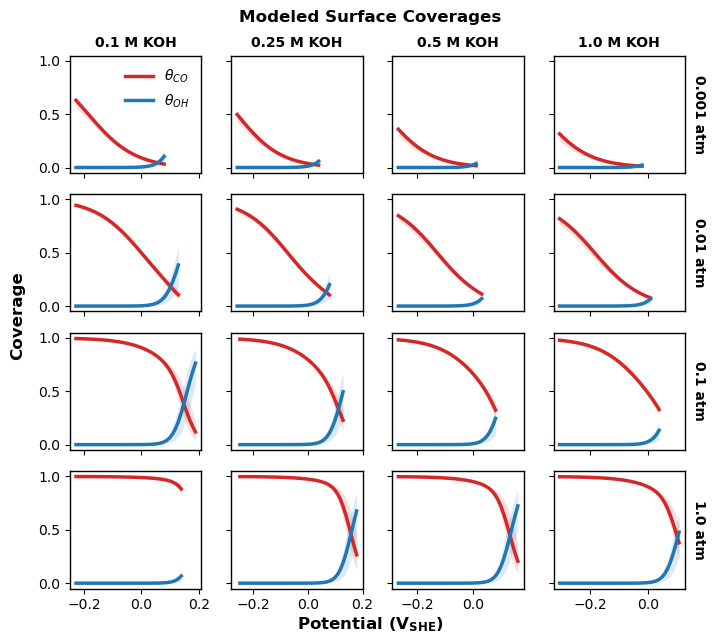

In [3]:
ppc_ER_1_2 = plot_posteriors(trace_ER_1_2, ER_1_2, plot_target)
plot_model_fits(trace_ER_1_2, ppc_ER_1_2); plot_coverages(trace_ER_1_2)

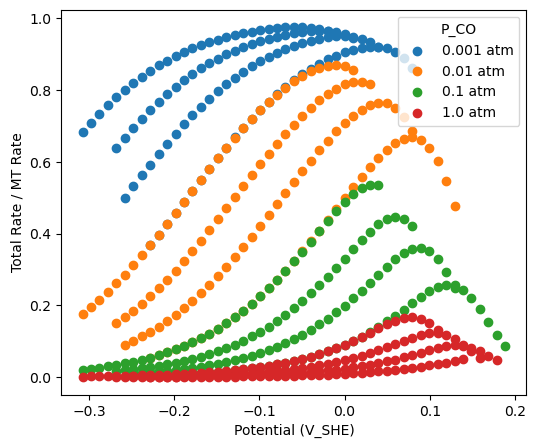

In [5]:
phi_LH_mean = trace_ER_1_2.posterior['phi_fick'].mean(dim=['chain', 'draw'])
plt.figure(figsize=(6, 5))
for p in np.unique(P_CO_in):
    mask = (P_CO_in == p)
    plt.scatter(E_in[mask], 1/(phi_LH_mean[mask]), label=f'{p} atm')
plt.xlabel('Potential (V_SHE)')
plt.ylabel('Total Rate / MT Rate')
plt.legend(title='P_CO')
plt.show()

Sampling: [rate]


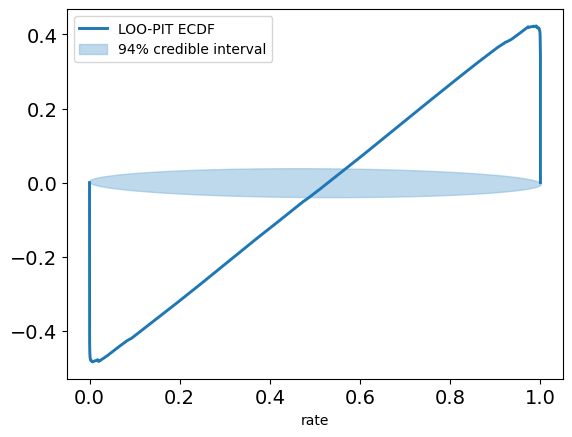

In [6]:
with ER_1_2: ppc = pm.sample_posterior_predictive(trace_ER_1_2, extend_inferencedata=True, progressbar=False)
az.plot_loo_pit(trace_ER_1_2, y='rate', ecdf=True)
plt.show()

# Comparison
ER_1_2. CO adsorption is rate limited and has highest weight and ELPD. 

         rank     elpd_loo      p_loo   elpd_diff        weight         se        dse  warning scale
ER_1_2      0  1358.305938   7.437581    0.000000  9.356373e-01  37.158999   0.000000    False   log
ER_2_3      1  1101.192556  13.096908  257.113382  6.436268e-02  31.860473  26.371630    False   log
ER_2        2  1072.823523  10.887434  285.482415  0.000000e+00  33.451948  25.003628    False   log
ER_LH_2     3  1072.496047  11.097259  285.809891  2.034539e-10  33.411370  25.019323    False   log


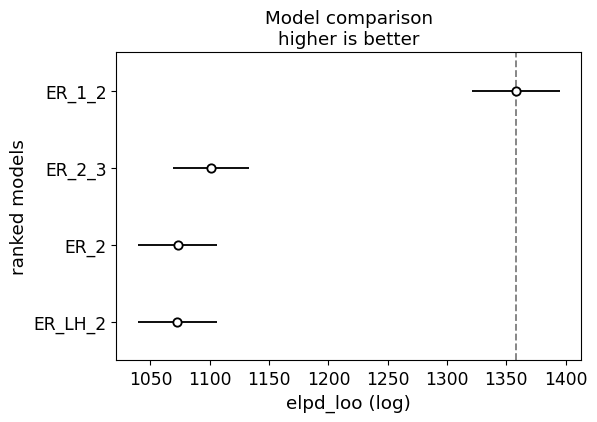

In [15]:
comparison_dict = {
    "ER_2": loo_ER_2,
    'ER_LH_2': loo_ER_LH_2,
    "ER_2_3": loo_ER_2_3,
    "ER_1_2": loo_ER_1_2
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()

# ER 1 2 Kinetics
CO adsorption is not kinetically limited. CO is strongly bound. 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.13,15
,3000,0,0.13,31
,3000,0,0.15,15
,3000,0,0.13,15


Computed from 4000 posterior samples and 581 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  1358.99    37.21
p_loo        6.39        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      581  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



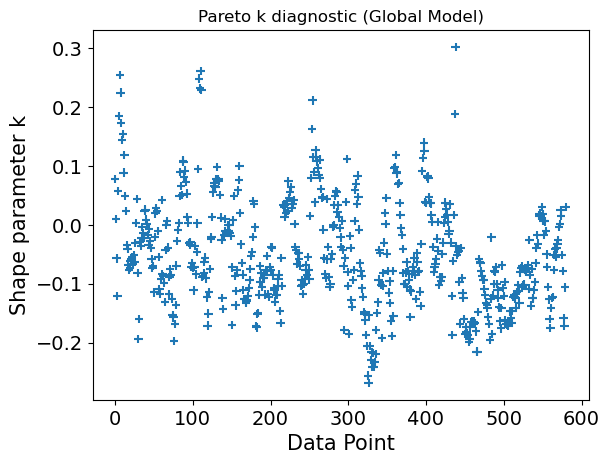

In [16]:
with pm.Model() as ER_1_2_kin: 
    '''
    1. CO + * <-> CO* (Fick) (SSA)
    2. CO* + OH- -> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    Gact1_0 = pm.Normal('Gact1_0', mu=0.7, sigma=0.1) # Kinetic barrier for adsorption
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.75, sigma=0.1) # at 0V_SHE
    delta_BL = 8.17 # in microns

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1_fick_term = log_k1_fick - pt.log(delta_BL)
    log_k1_kin = np.log(kb_J*T/h) - Gact1_0/(kb_eV*T)
    log_k1_eff = -pt.logaddexp(-log_k1_fick_term, -log_k1_kin) 
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    log_denom_CO = pt.logaddexp(log_k1_kin - log_K1, log_k2 + np.log(C_KOH_in))
    term_CO = log_k1_eff + np.log(P_CO_in) - log_denom_CO
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_model = log_k2 + np.log(C_KOH_in) + log_theta_CO 
    log_rate = observables(log_rate_model) 

trace_ER_1_2_kin, loo_ER_1_2_kin = fit_and_evaluate(ER_1_2_kin, target_accept=0.99)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.543  0.133  -0.785   -0.335      0.004    0.003    1148.0    1767.0   1.00
Gact1_0    0.557  0.043   0.474    0.621      0.001    0.001    1560.0    1468.0   1.00
deltaG4_0  0.084  0.005   0.075    0.093      0.000    0.000    2636.0    2227.0   1.00
Gact2_0    0.745  0.001   0.743    0.746      0.000    0.000    1778.0    2377.0   1.00
beta_2     0.281  0.006   0.271    0.292      0.000    0.000    1914.0    2456.0   1.00
sigma      0.315  0.013   0.291    0.339      0.000    0.000    3230.0    2539.0   1.01


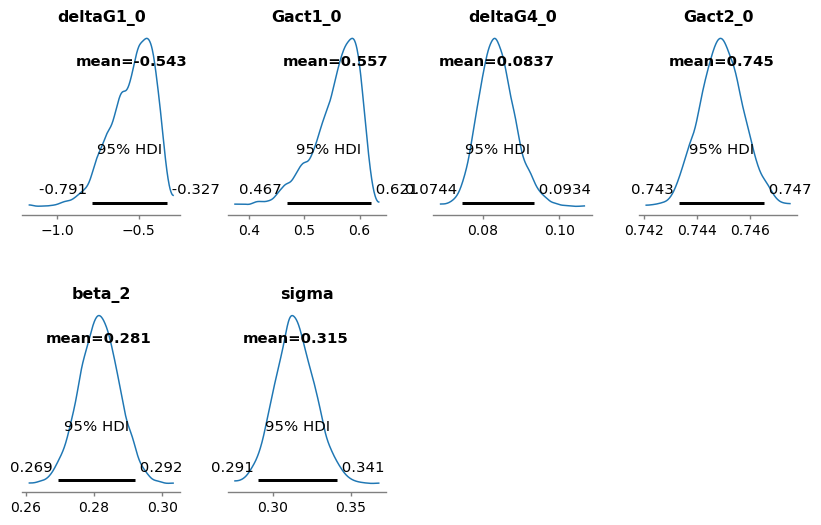

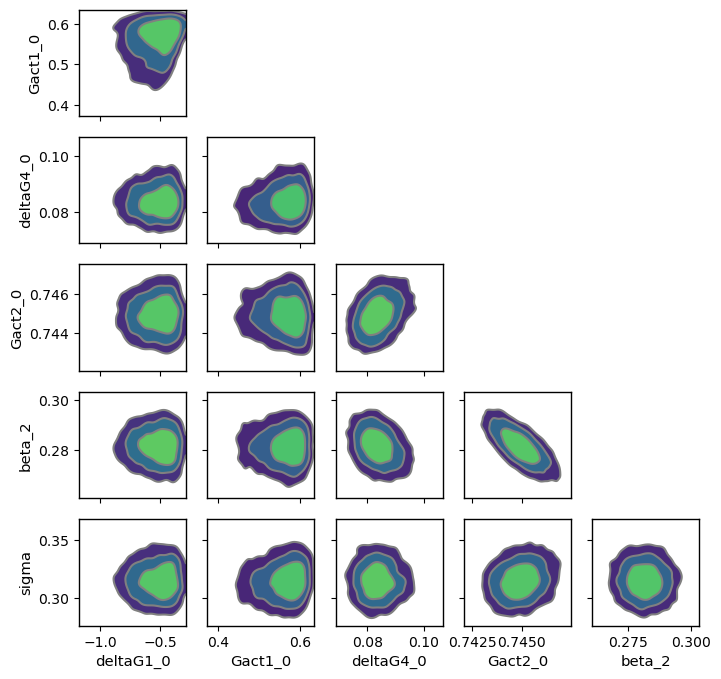

Sampling: [rate]


rate: 0.790


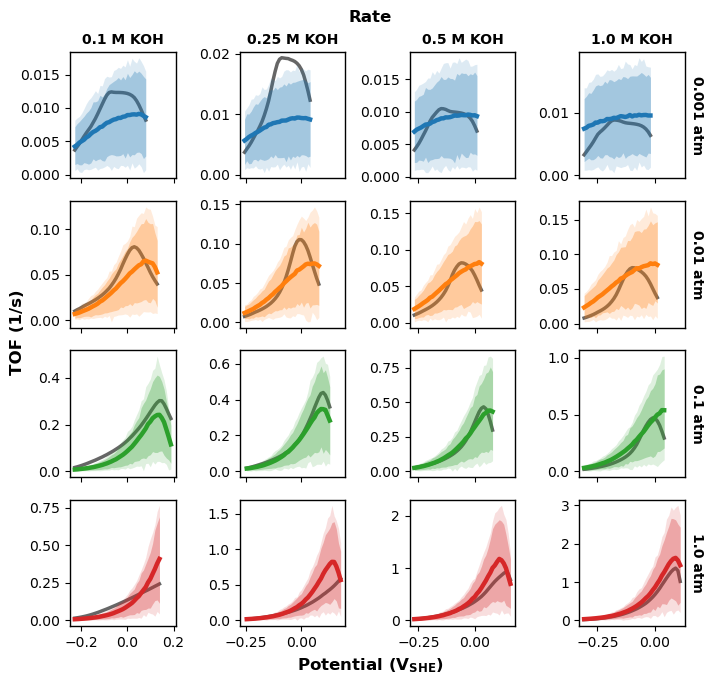

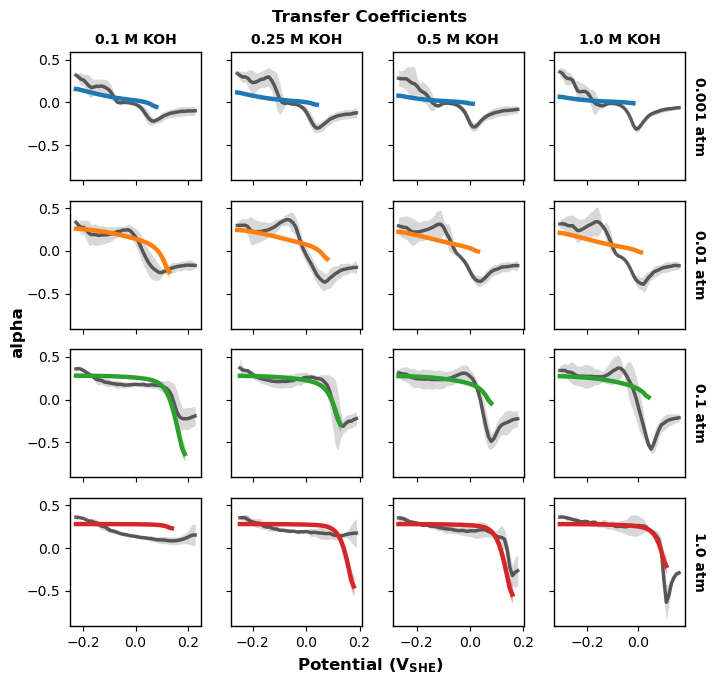

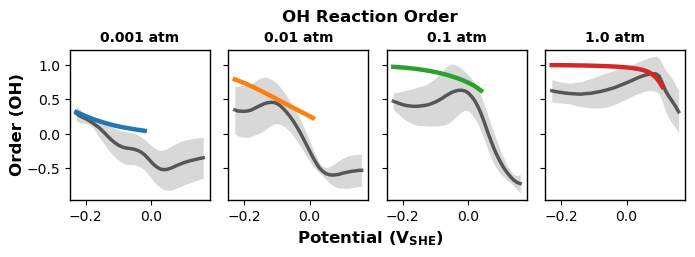

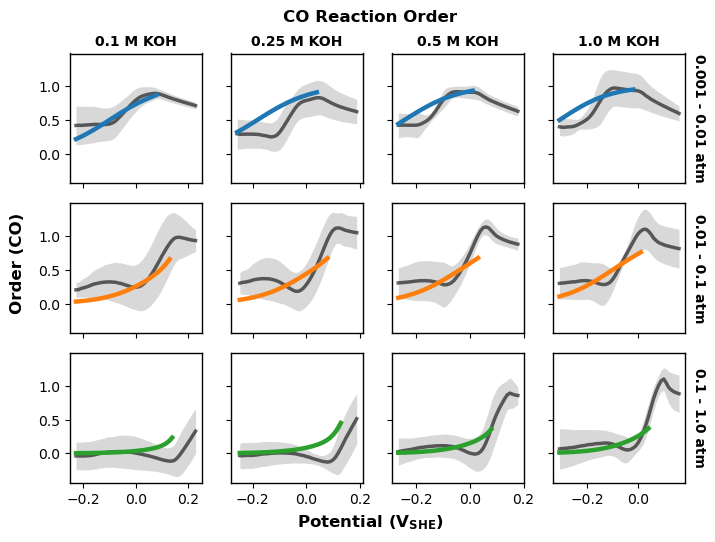

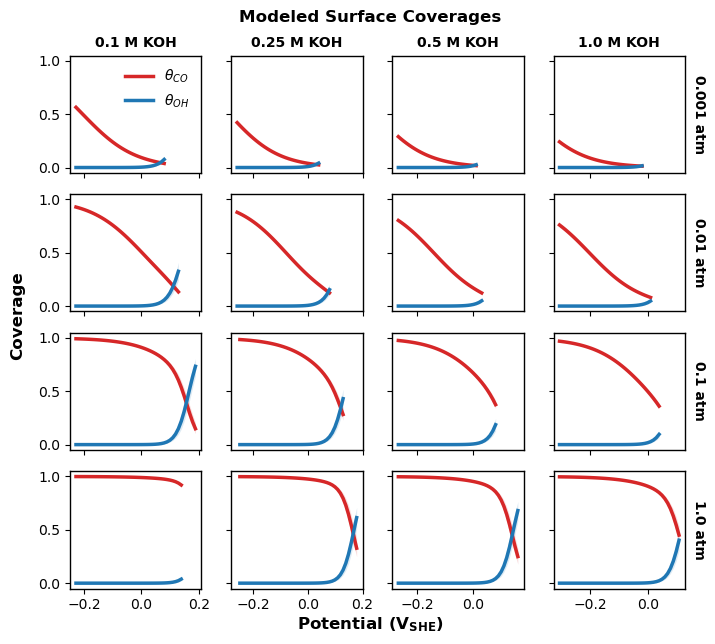

In [17]:
ppc_ER_1_2_kin = plot_posteriors(trace_ER_1_2_kin, ER_1_2_kin, plot_target)
plot_model_fits(trace_ER_1_2_kin, ppc_ER_1_2_kin); plot_coverages(trace_ER_1_2_kin)

# ER LH 1 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.36,7
,3000,0,0.38,7
,3000,0,0.37,7
,3000,0,0.34,15


Computed from 4000 posterior samples and 581 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  1358.35    37.14
p_loo        7.47        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      581  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



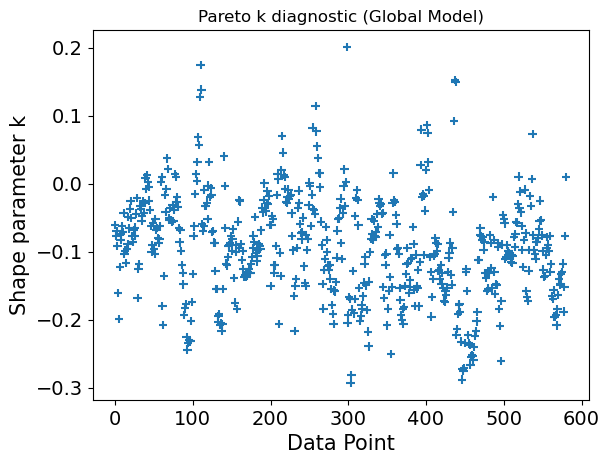

In [18]:
with pm.Model() as ER_LH_1_2:
    '''
    1. CO + * <-> CO* (Fick) (Irr) (SSA)
    2a. CO* + OH- -> COOH* + (e-) (SSA)
    2b. CO* + OH* -> COOH* + * (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.75, sigma=0.1) # at 0V_SHE
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.75, sigma=0.1)
    delta_BL = pm.TruncatedNormal('delta_BL', mu=10, sigma=5, lower=0) # in microns

    # Thermodynamics 
    deltaG4 = deltaG4_0 - E_in
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1 = log_k1_fick - pt.log(delta_BL)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_OH = log_K4 + np.log(C_KOH_in)
    gamma_OH_lin = pt.exp(term_OH)
    k1_fwd_lin = pt.exp(log_k1 + np.log(P_CO_in))
    k2_ER_lin = pt.exp(log_k2_ER + np.log(C_KOH_in))
    k2_LH_lin = pt.exp(log_k2_LH + term_OH)
    site_block = 1.0 + gamma_OH_lin
    a_term = k2_ER_lin
    b_term = k2_ER_lin * site_block + k2_LH_lin - k1_fwd_lin
    c_term = - k1_fwd_lin * site_block
    gamma_CO_lin = (-b_term + pt.sqrt(b_term**2 - 4 * a_term * c_term)) / (2 * a_term)
    term_CO = pt.log(gamma_CO_lin)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    
    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_ER = log_k2_ER + np.log(C_KOH_in) + log_theta_CO
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate_model = pt.logaddexp(log_rate_ER, log_rate_LH)
    log_rate = observables(log_rate_model) 

    phi_LH = pm.Deterministic('phi_LH', pt.exp(log_rate_LH - log_rate_model))

trace_ER_LH_1_2, loo_ER_LH_1_2 = fit_and_evaluate(ER_LH_1_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0   0.082  0.005   0.073    0.092      0.000    0.000    2346.0    2601.0    1.0
Gact2_ER_0  0.745  0.001   0.744    0.747      0.000    0.000    1852.0    2070.0    1.0
Gact2_LH_0  0.827  0.058   0.745    0.937      0.002    0.001    1505.0    1538.0    1.0
beta_2      0.280  0.006   0.270    0.292      0.000    0.000    1727.0    2085.0    1.0
delta_BL    8.169  0.263   7.681    8.666      0.005    0.004    3199.0    3208.0    1.0
sigma       0.314  0.013   0.289    0.338      0.000    0.000    2817.0    2610.0    1.0


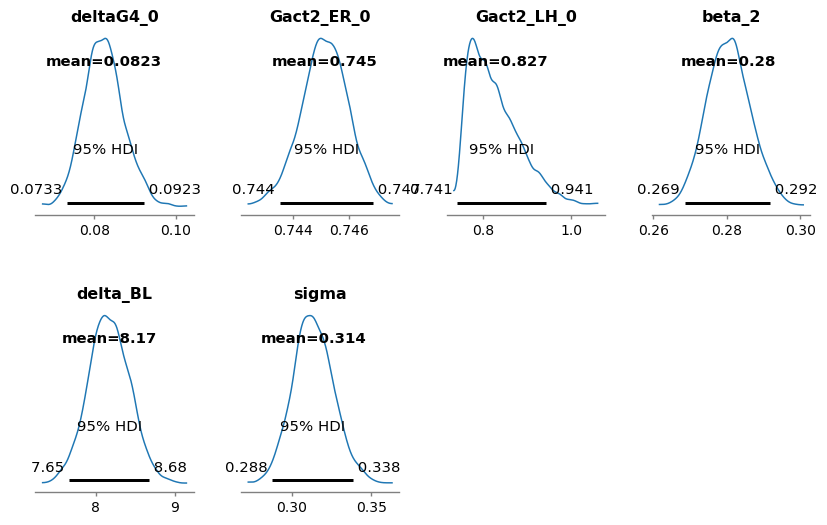

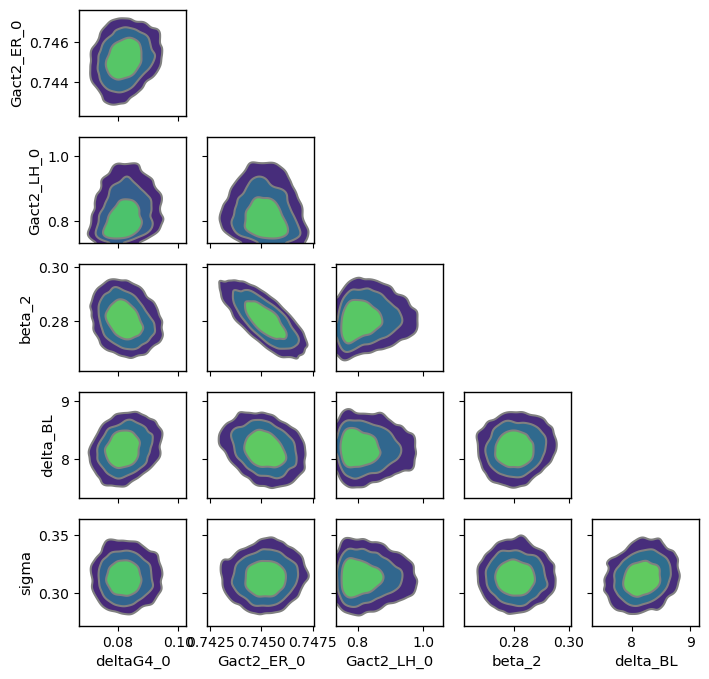

Sampling: [rate]


rate: 0.791


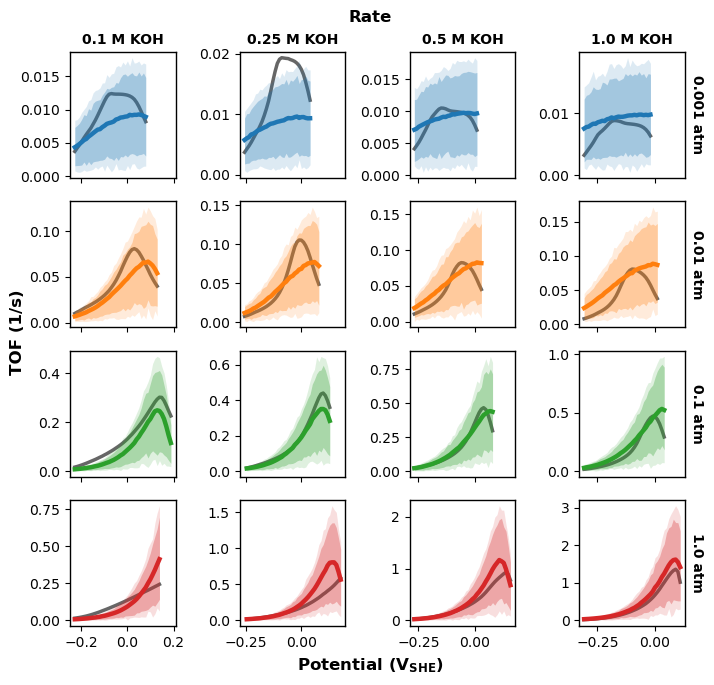

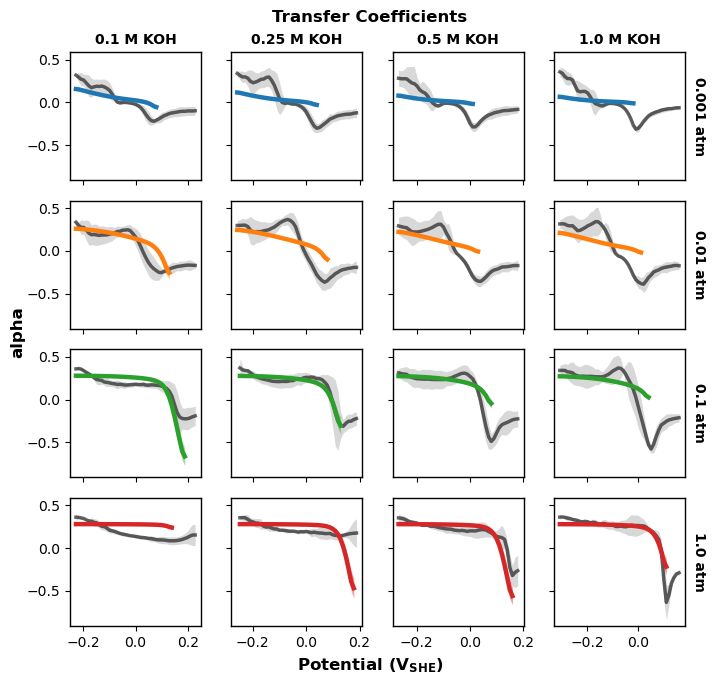

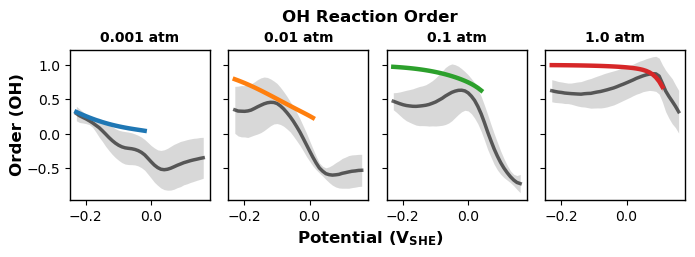

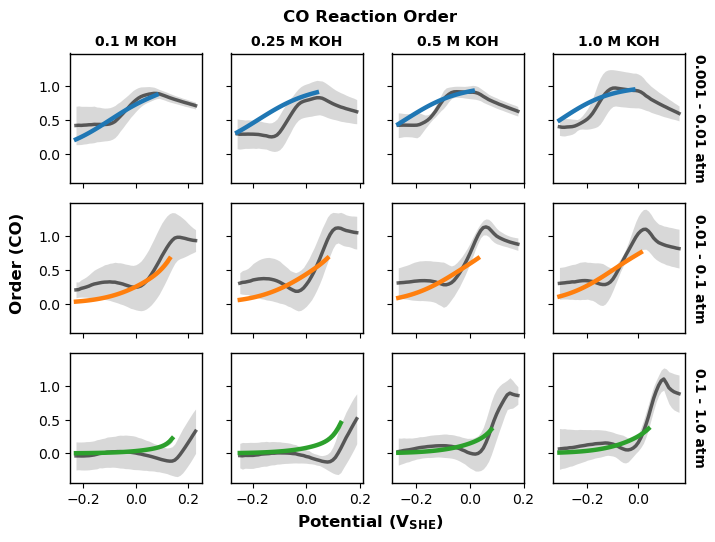

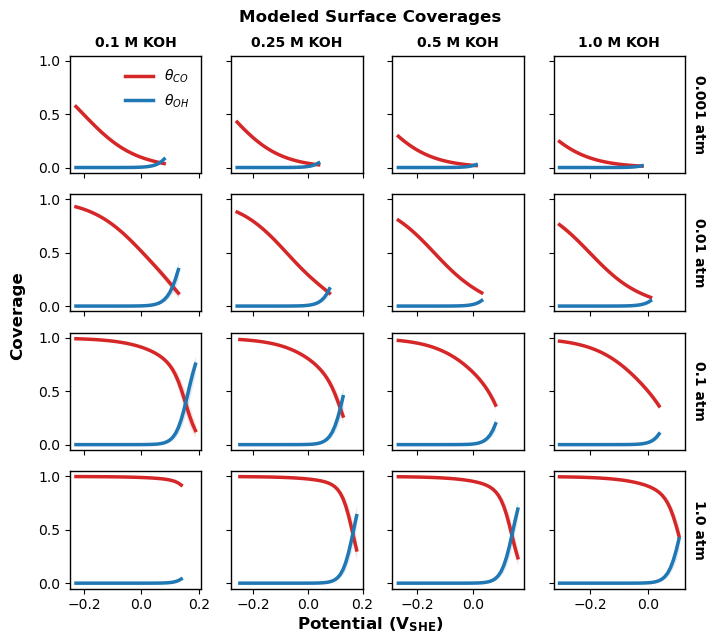

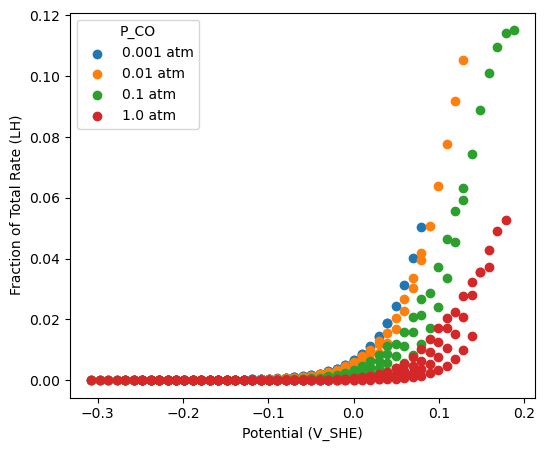

In [19]:
ppc_ER_LH_1_2 = plot_posteriors(trace_ER_LH_1_2, ER_LH_1_2, plot_target)
plot_model_fits(trace_ER_LH_1_2, ppc_ER_LH_1_2); plot_coverages(trace_ER_LH_1_2)

phi_LH_mean = trace_ER_LH_1_2.posterior['phi_LH'].mean(dim=['chain', 'draw'])
plt.figure(figsize=(6, 5))
for p in np.unique(P_CO_in):
    mask = (P_CO_in == p)
    plt.scatter(E_in[mask], phi_LH_mean[mask], label=f'{p} atm')
plt.xlabel('Potential (V_SHE)')
plt.ylabel('Fraction of Total Rate (LH)')
plt.legend(title='P_CO')
plt.show()

# ER 1 2 3

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.12,95
,3000,0,0.13,15
,3000,0,0.14,31
,3000,0,0.13,31


Computed from 4000 posterior samples and 581 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  1402.86    36.28
p_loo        9.61        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      581  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



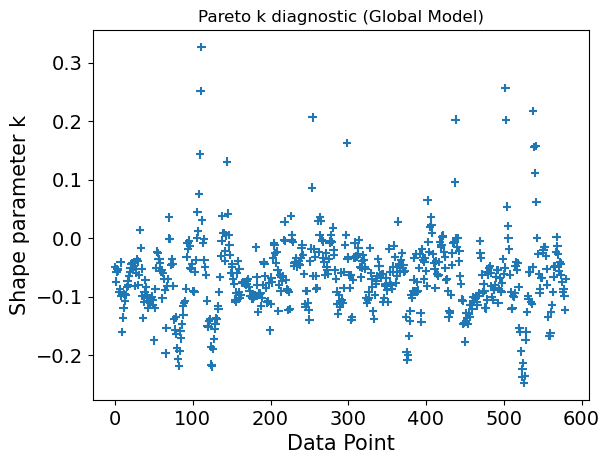

In [36]:
with pm.Model() as ER_1_2_3:
    '''
    1. CO + * <-> CO* (Fick) (Irr) (SSA)
    2. CO* + OH- <-> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (SSA) (Irr)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    deltaG2_0 = pm.Normal('deltaG2_0', mu=0.0, sigma=0.5) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    beta_3 = pm.Beta('beta_3', alpha=5, beta=5)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.75, sigma=0.1) # at 0V_SHE
    Gact3_0 = pm.Normal('Gact3_0', mu=0.75, sigma=0.1) # at 0V_SHE
    delta_BL = pm.TruncatedNormal('delta_BL', mu=10, sigma=5, lower=0) # in microns

    # Thermodynamics 
    deltaG4 = deltaG4_0 - E_in
    deltaG2 = deltaG2_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in
    log_K4 = -deltaG4/(kb_eV*T)
    log_K2 = -deltaG2/(kb_eV*T)
    log_k1 = log_k1_fick - pt.log(delta_BL)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)

    log_denom_COOH = pt.logaddexp(log_k2 - log_K2, log_k3 + np.log(C_KOH_in))
    log_k2_k3_term = log_k2 + log_k3 + 2*np.log(C_KOH_in) - log_denom_COOH
    term_CO = log_k1 + np.log(P_CO_in) - log_k2_k3_term
    term_OH = log_K4 + np.log(C_KOH_in)
    term_COOH = log_k2 + np.log(C_KOH_in) - log_denom_COOH + term_CO
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH, term_COOH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression
    log_rate_model = log_k3 + np.log(C_KOH_in) + log_theta_COOH
    log_rate = observables(log_rate_model) 

trace_ER_1_2_3, loo_ER_1_2_3 = fit_and_evaluate(ER_1_2_3, target_accept=0.95)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0  0.106  0.014   0.087    0.128      0.001    0.002    1171.0     850.0   1.00
deltaG2_0 -0.671  0.249  -1.145   -0.353      0.008    0.007    1263.0    1100.0   1.00
Gact2_0    0.723  0.038   0.648    0.747      0.018    0.011       7.0      49.0   1.53
Gact3_0    0.682  0.039   0.635    0.747      0.018    0.008       7.0      32.0   1.53
beta_2     0.297  0.183   0.146    0.655      0.089    0.053       7.0      38.0   1.53
beta_3     0.499  0.185   0.172    0.706      0.088    0.046       7.0      36.0   1.54
delta_BL   8.315  0.266   7.830    8.822      0.005    0.004    3390.0    2524.0   1.00
sigma      0.301  0.012   0.280    0.324      0.000    0.000    4256.0    2768.0   1.00


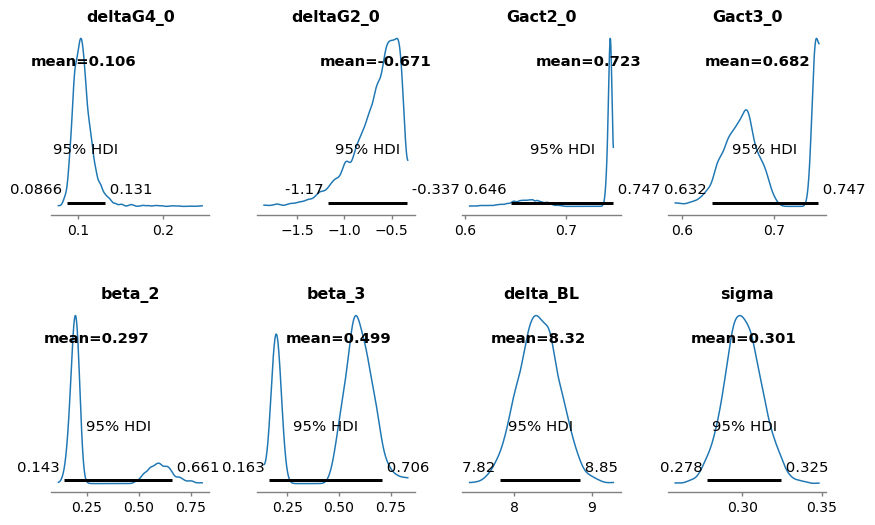

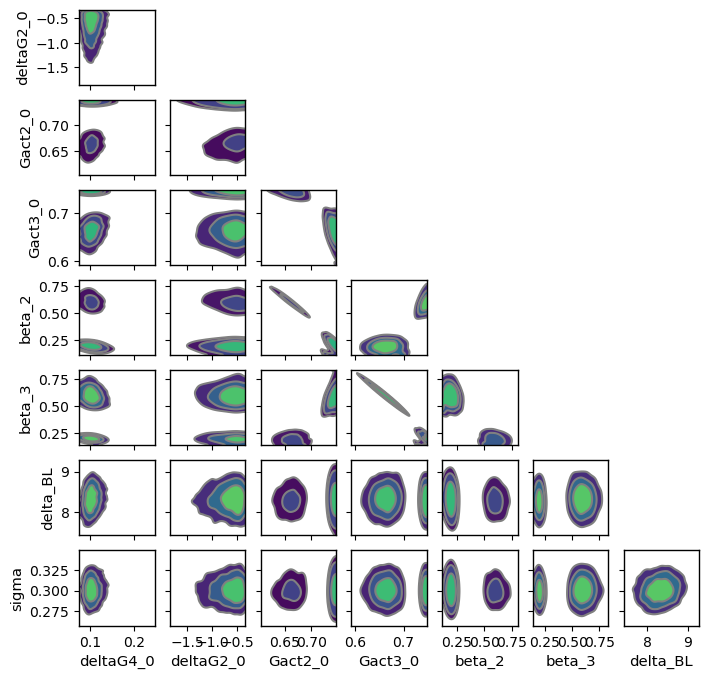

Sampling: [rate]


rate: 0.809


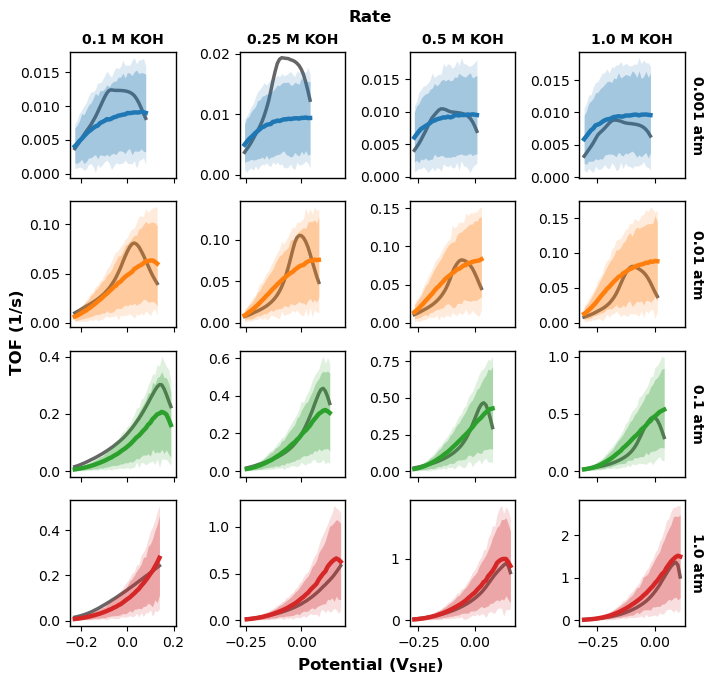

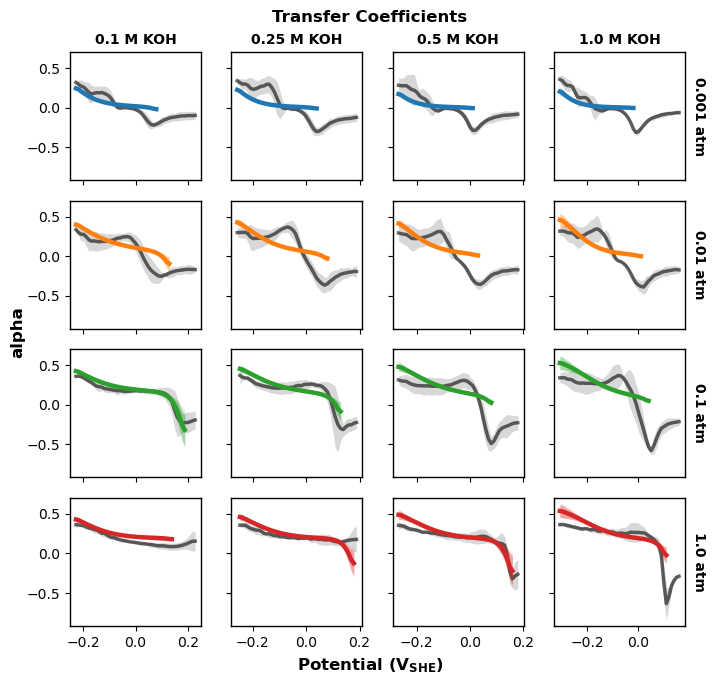

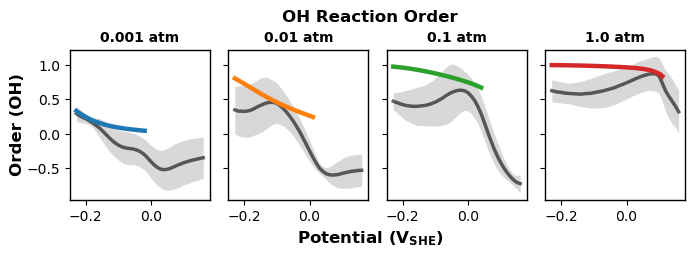

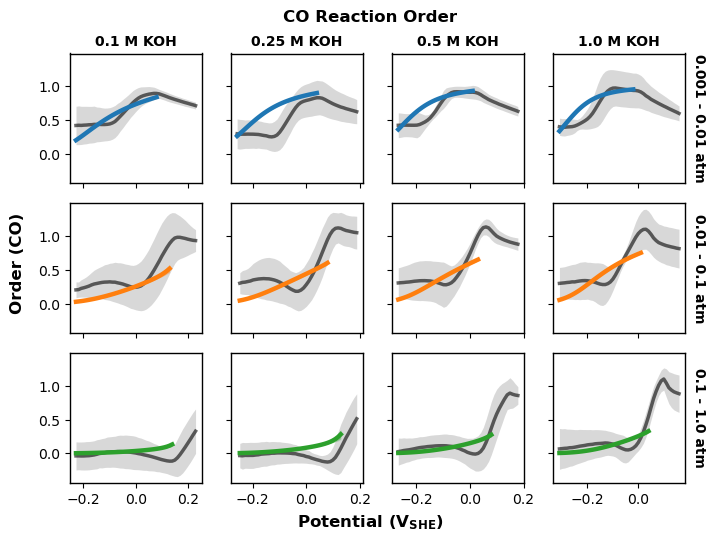

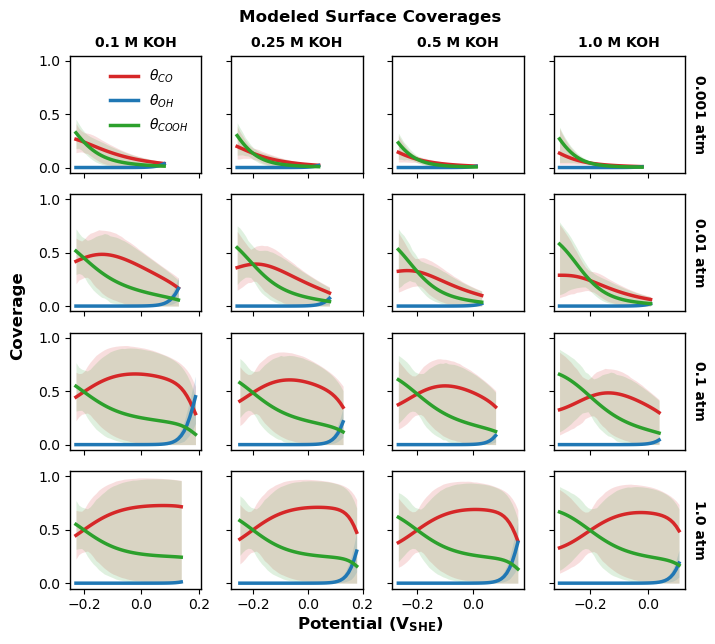

In [37]:
ppc_ER_1_2_3 = plot_posteriors(trace_ER_1_2_3, ER_1_2_3, plot_target)
plot_model_fits(trace_ER_1_2_3, ppc_ER_1_2_3); plot_coverages(trace_ER_1_2_3)

## Biased towards 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.16,63
,3000,0,0.15,15
,3000,0,0.15,63
,3000,0,0.16,15


Computed from 4000 posterior samples and 581 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  1403.38    36.24
p_loo        9.08        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      581  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



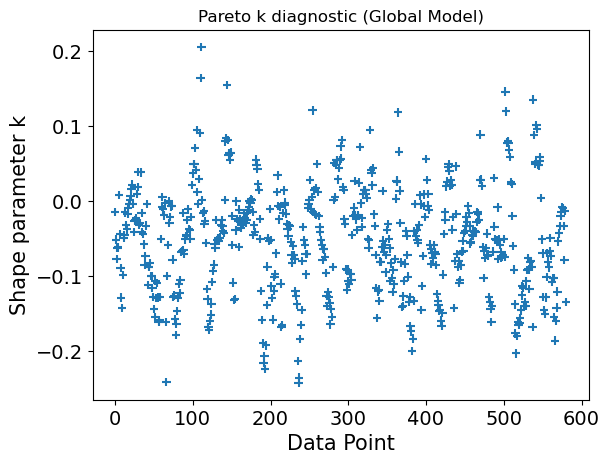

In [40]:
with pm.Model() as ER_1_2_3:
    '''
    1. CO + * <-> CO* (Fick) (Irr) (SSA)
    2. CO* + OH- <-> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (SSA) (Irr)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    deltaG2_0 = pm.Normal('deltaG2_0', mu=-0.5, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    beta_3 = pm.Beta('beta_3', alpha=5, beta=5)
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.75, sigma=0.02, lower=0.7) # at 0V_SHE
    Gact3_0 = pm.TruncatedNormal('Gact3_0', mu=0.65, sigma=0.02, upper=0.7) # at 0V_SHE
    delta_BL = pm.TruncatedNormal('delta_BL', mu=10, sigma=5, lower=0) # in microns

    # Thermodynamics 
    deltaG4 = deltaG4_0 - E_in
    deltaG2 = deltaG2_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in
    log_K4 = -deltaG4/(kb_eV*T)
    log_K2 = -deltaG2/(kb_eV*T)
    log_k1 = log_k1_fick - pt.log(delta_BL)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)

    log_denom_COOH = pt.logaddexp(log_k2 - log_K2, log_k3 + np.log(C_KOH_in))
    log_k2_k3_term = log_k2 + log_k3 + 2*np.log(C_KOH_in) - log_denom_COOH
    term_CO = log_k1 + np.log(P_CO_in) - log_k2_k3_term
    term_OH = log_K4 + np.log(C_KOH_in)
    term_COOH = log_k2 + np.log(C_KOH_in) - log_denom_COOH + term_CO
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH, term_COOH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression
    log_rate_model = log_k3 + np.log(C_KOH_in) + log_theta_COOH
    log_rate = observables(log_rate_model) 

trace_ER_1_2_3, loo_ER_1_2_3 = fit_and_evaluate(ER_1_2_3, target_accept=0.95)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0  0.104  0.015   0.087    0.125      0.001    0.004    1876.0    1370.0    1.0
deltaG2_0 -0.594  0.146  -0.862   -0.360      0.003    0.002    2505.0    2133.0    1.0
beta_2     0.200  0.015   0.172    0.225      0.001    0.000     846.0    1145.0    1.0
beta_3     0.624  0.050   0.533    0.722      0.002    0.001     609.0     910.0    1.0
Gact2_0    0.744  0.001   0.742    0.746      0.000    0.000    1063.0    1291.0    1.0
Gact3_0    0.654  0.014   0.627    0.680      0.001    0.000     595.0     793.0    1.0
delta_BL   8.311  0.259   7.855    8.833      0.004    0.004    3912.0    2717.0    1.0
sigma      0.301  0.011   0.280    0.322      0.000    0.000    3943.0    2753.0    1.0


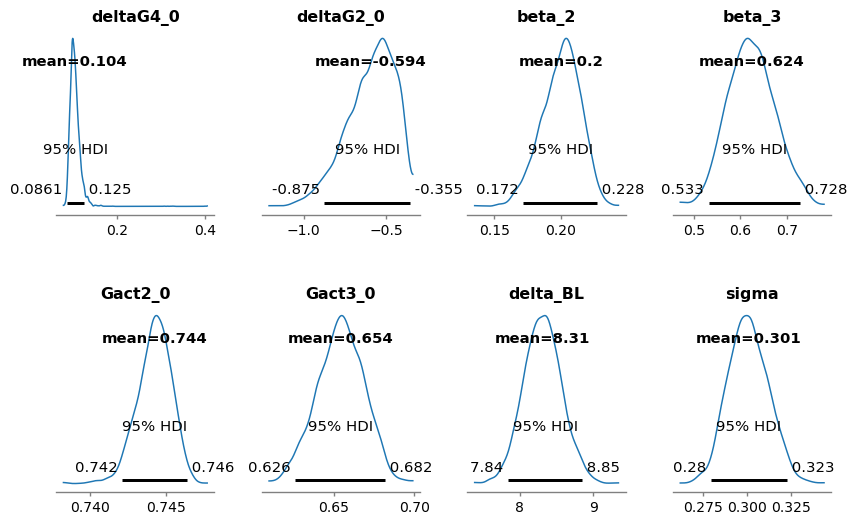

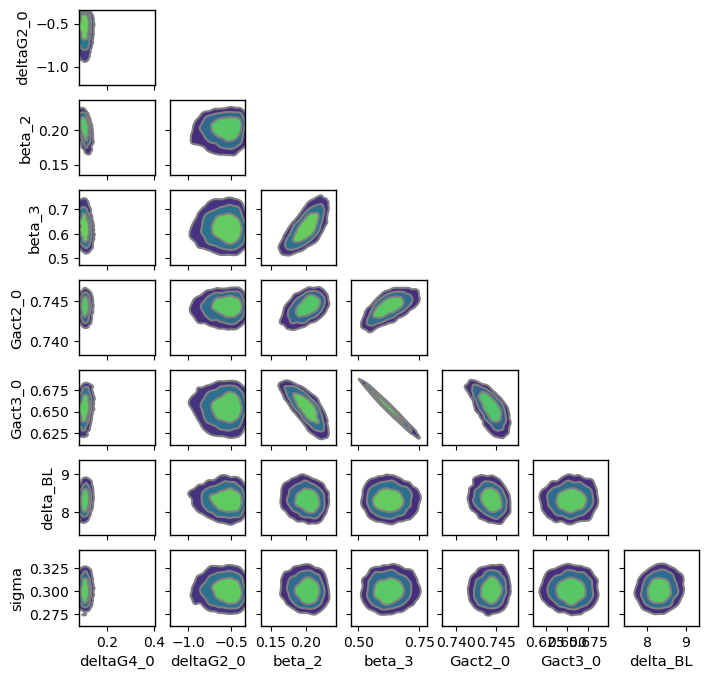

Sampling: [rate]


rate: 0.808


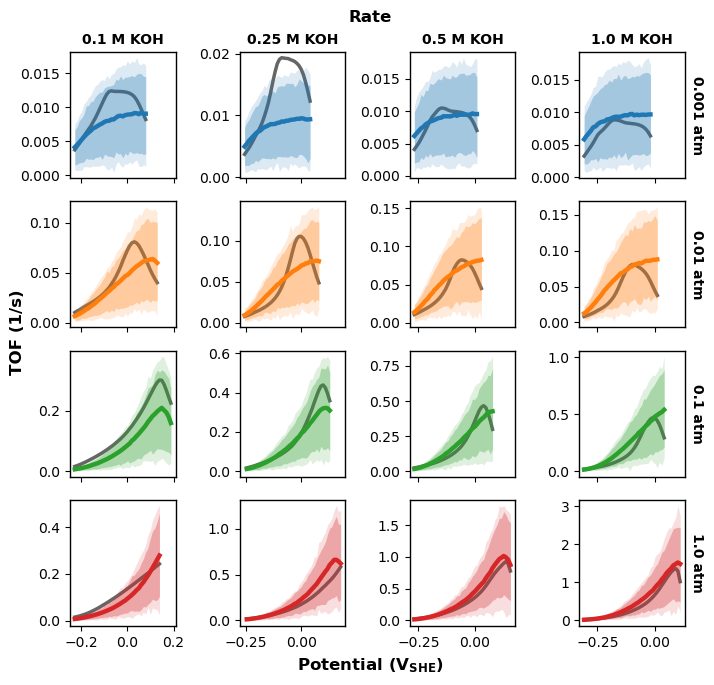

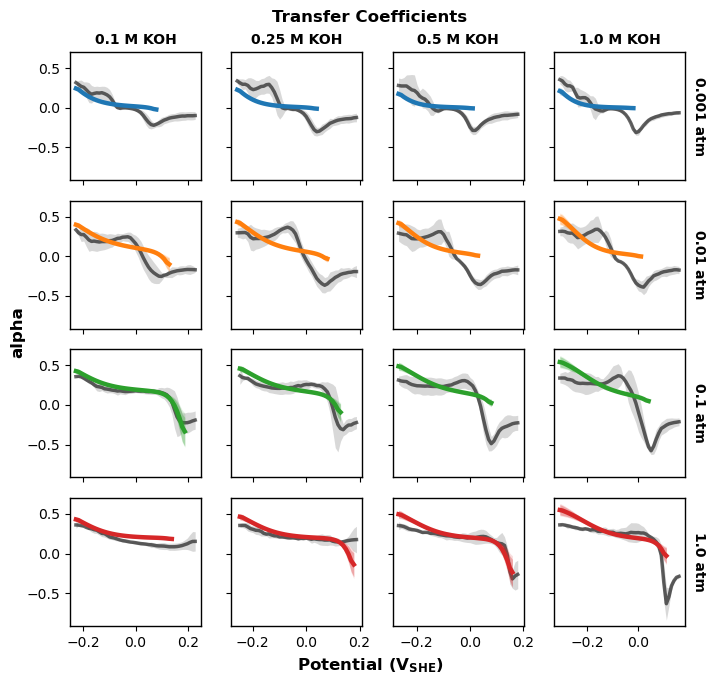

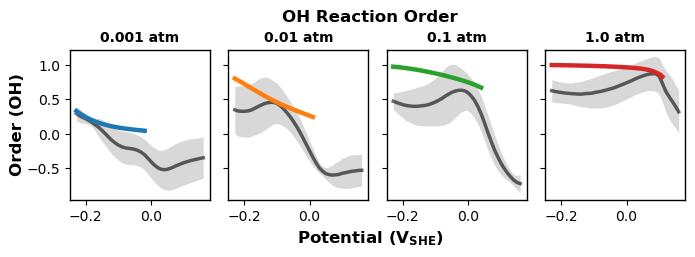

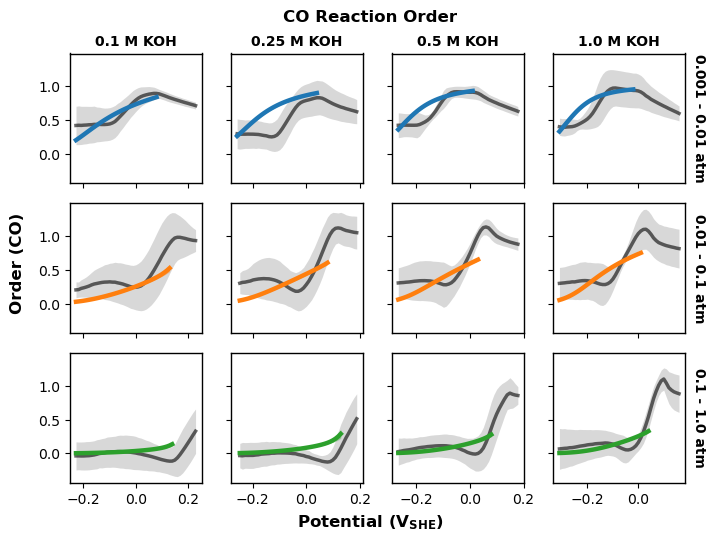

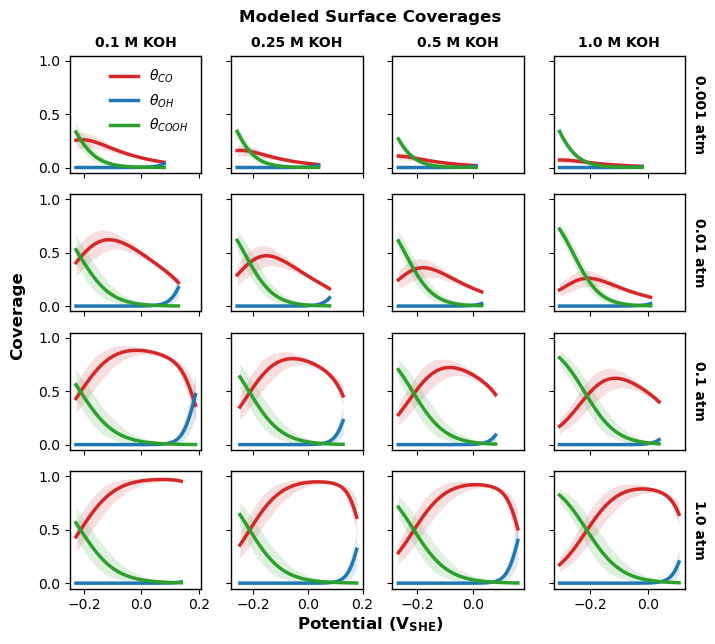

In [41]:
ppc_ER_1_2_3 = plot_posteriors(trace_ER_1_2_3, ER_1_2_3, plot_target)
plot_model_fits(trace_ER_1_2_3, ppc_ER_1_2_3); plot_coverages(trace_ER_1_2_3)

# Comparison
ER_1_2 is great. ER_LH_1_2 is slightly better, but it is statistically insignificant. ER_1_2_3 is better, but physically unjustifiable. 

          rank     elpd_loo     p_loo  elpd_diff  weight         se       dse  warning scale
ER_1_2_3     0  1403.384214  9.082206   0.000000     1.0  36.244807  0.000000    False   log
ER_1_2       1  1358.305938  7.437581  45.078276     0.0  37.158999  9.973603    False   log


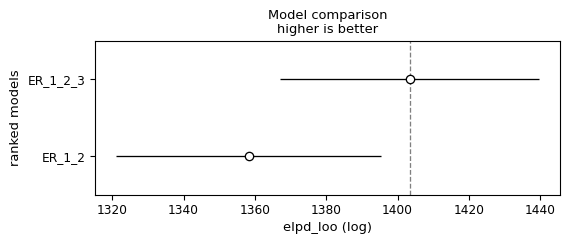

In [42]:
comparison_dict = {
    "ER_1_2": loo_ER_1_2,
    # "ER_LH_1_2": loo_ER_LH_1_2,
    "ER_1_2_3": loo_ER_1_2_3
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()